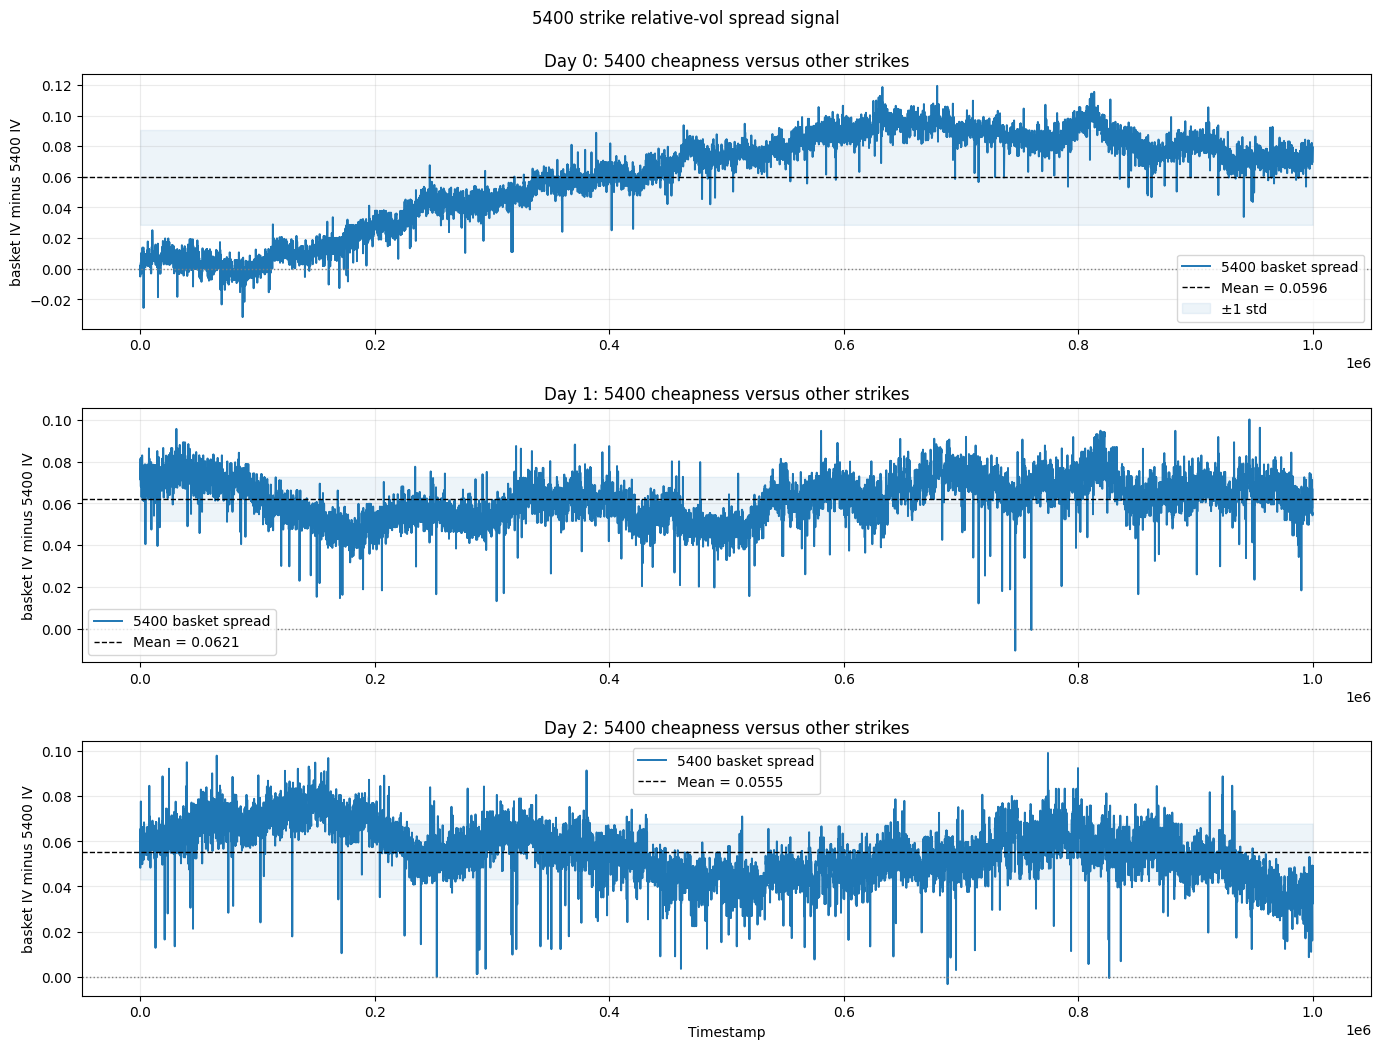

5400 vs basket spread summary
 day  mean_spread  std_spread  min_spread  max_spread  lag1_acf  half_life_ticks      p10      p50      p90
   0     0.059587    0.030951   -0.031615    0.119340  0.973074        25.394439 0.007559 0.069769 0.092638
   1     0.062145    0.010541   -0.010583    0.100209  0.677521         1.780428 0.048454 0.062336 0.075469
   2     0.055451    0.012417   -0.003337    0.099142  0.700244         1.945263 0.039975 0.055367 0.071352

Signal counts by day
trade_signal  buy_5400_short_basket  flat  sell_5400_long_basket
day                                                             
0                              1391  6521                   2088
1                              1606  6757                   1637
2                              1673  6839                   1488


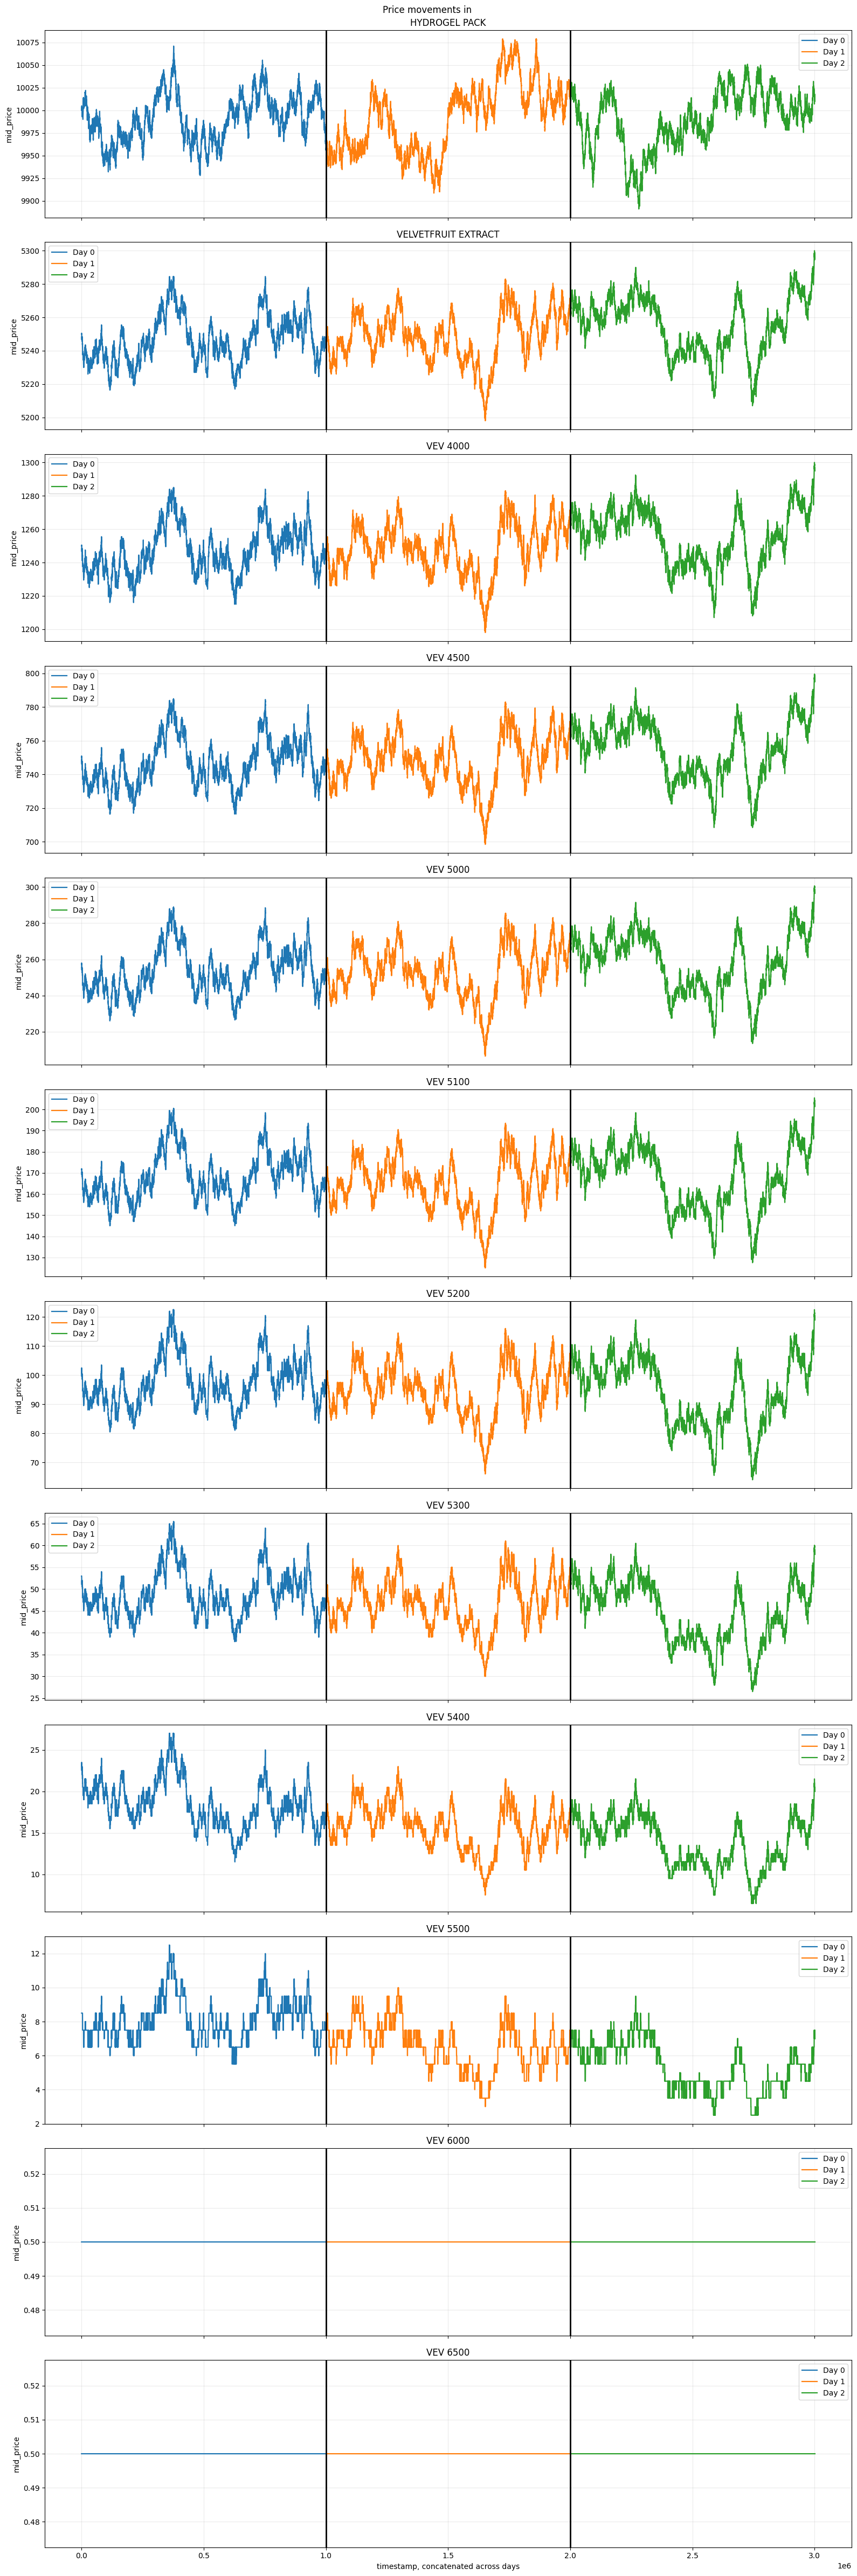

In [17]:
from pathlib import Path
import re

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

ROUND_NUMBER = 3
ROUND_FOLDER = Path(".")
# 5400 strike versus the rest of the smile basket
# Positive spread means 5400 is cheap relative to the average of the other strikes.

if 'rv_df' not in globals():
    raise ValueError("Run the relative-vol analysis cells first to create rv_df.")

target_strike = 5400
other_strikes = [strike for strike in strikes_rv if strike != target_strike]

spread_frames = []
for day in days_rv:
    day_slice = rv_df[rv_df['day'] == day].copy()
    if day_slice.empty:
        continue

    pivot_day = day_slice.pivot_table(index='timestamp', columns='strike', values='rel_vol_dev').sort_index()
    if target_strike not in pivot_day.columns:
        continue

    basket_cols = [strike for strike in other_strikes if strike in pivot_day.columns]
    if not basket_cols:
        continue

    spread = pivot_day[basket_cols].mean(axis=1) - pivot_day[target_strike]
    spread = spread.dropna().rename('spread')
    if spread.empty:
        continue

    day_stats = pd.DataFrame({
        'day': day,
        'timestamp': spread.index.astype(float),
        'spread': spread.to_numpy(),
    })
    day_stats['zscore'] = (day_stats['spread'] - day_stats['spread'].mean()) / day_stats['spread'].std(ddof=0)
    spread_frames.append(day_stats)

if not spread_frames:
    raise ValueError("Could not build a 5400-vs-basket spread from the available smile data.")

spread_df = pd.concat(spread_frames, ignore_index=True)

summary_rows = []
for day, day_df in spread_df.groupby('day'):
    values = day_df['spread'].to_numpy()
    rho = float(np.corrcoef(values[:-1], values[1:])[0, 1]) if len(values) > 2 else np.nan
    half_life = -np.log(2) / np.log(abs(rho)) if 0 < abs(rho) < 1 else np.nan
    summary_rows.append({
        'day': int(day),
        'mean_spread': float(np.mean(values)),
        'std_spread': float(np.std(values, ddof=0)),
        'min_spread': float(np.min(values)),
        'max_spread': float(np.max(values)),
        'lag1_acf': rho,
        'half_life_ticks': half_life,
        'p10': float(np.quantile(values, 0.10)),
        'p50': float(np.quantile(values, 0.50)),
        'p90': float(np.quantile(values, 0.90)),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('day')

fig, axes = plt.subplots(len(days_rv), 1, figsize=(14, 3.5 * len(days_rv)), sharex=False)
if len(days_rv) == 1:
    axes = [axes]

for ax, day in zip(axes, days_rv):
    day_df = spread_df[spread_df['day'] == day].sort_values('timestamp')
    if day_df.empty:
        continue

    ax.plot(day_df['timestamp'], day_df['spread'], color='tab:blue', linewidth=1.4, label='5400 basket spread')
    ax.axhline(day_df['spread'].mean(), color='black', linestyle='--', linewidth=1, label=f"Mean = {day_df['spread'].mean():.4f}")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)

    upper = day_df['spread'].mean() + day_df['spread'].std(ddof=0)
    lower = day_df['spread'].mean() - day_df['spread'].std(ddof=0)
    ax.fill_between(day_df['timestamp'], lower, upper, color='tab:blue', alpha=0.08, label='±1 std' if day == days_rv[0] else None)

    ax.set_title(f"Day {day}: 5400 cheapness versus other strikes")
    ax.set_ylabel('basket IV minus 5400 IV')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Timestamp')
fig.suptitle('5400 strike relative-vol spread signal', y=0.995)
fig.tight_layout()
plt.show()

print('5400 vs basket spread summary')
print(summary_df.to_string(index=False))

current = spread_df.copy()
current['trade_signal'] = np.where(current['zscore'] > 1.0, 'buy_5400_short_basket', np.where(current['zscore'] < -1.0, 'sell_5400_long_basket', 'flat'))
print()
print('Signal counts by day')
print(current.groupby(['day', 'trade_signal']).size().unstack(fill_value=0).to_string())
PRICE_FILES = sorted(ROUND_FOLDER.glob(f"prices_round_{ROUND_NUMBER}_day_*.csv"))
if not PRICE_FILES:
    raise FileNotFoundError(f"No price CSV files found in {ROUND_FOLDER}")

DAY_RE = re.compile(r"day_(-?\d+)\.csv$")
DAY_LABELS = []
frames = []
for file_path in PRICE_FILES:
    match = DAY_RE.search(file_path.name)
    if match is None:
        continue

    day = int(match.group(1))
    DAY_LABELS.append(day)

    df = pd.read_csv(file_path, sep=";")
    df["day"] = day
    df["timestamp"] = pd.to_numeric(df["timestamp"], errors="coerce")
    df["mid_price"] = pd.to_numeric(df["mid_price"], errors="coerce")
    frames.append(df[["day", "timestamp", "product", "mid_price"]])

if not frames:
    raise ValueError(f"No valid price data found in {ROUND_FOLDER}")

DAY_LABELS = sorted(set(DAY_LABELS))
prices = pd.concat(frames, ignore_index=True).dropna(subset=["timestamp", "mid_price"])
prices["timestamp"] = prices["timestamp"].astype(float)
plot_prices = prices.loc[prices["mid_price"] > 0].copy()
products = sorted(plot_prices["product"].dropna().unique())

# Build a continuous x-axis for the days and leave a visible gap between them.
gap = 1000.0
x_offsets = {}
separator_positions = []
current_offset = 0.0
for day in DAY_LABELS:
    day_prices = plot_prices[plot_prices["day"] == day]
    max_timestamp = float(day_prices["timestamp"].max()) if not day_prices.empty else 0.0
    x_offsets[day] = current_offset
    separator_positions.append(current_offset + max_timestamp + gap / 2)
    current_offset += max_timestamp + gap

fig, axes = plt.subplots(len(products), 1, figsize=(16, max(4, 4 * len(products))), sharex=True)
if len(products) == 1:
    axes = [axes]

cmap = plt.get_cmap("tab10")
color_map = {day: cmap(i % cmap.N) for i, day in enumerate(DAY_LABELS)}

for ax, product in zip(axes, products):
    product_prices = plot_prices[plot_prices["product"] == product].sort_values(["day", "timestamp"])

    for day in DAY_LABELS:
        day_prices = product_prices[product_prices["day"] == day].sort_values("timestamp")
        if day_prices.empty:
            continue

        x_values = day_prices["timestamp"] + x_offsets[day]
        ax.plot(
            x_values,
            day_prices["mid_price"],
            color=color_map[day],
            linewidth=1.6,
            label=f"Day {day}",
        )

    for separator in separator_positions[:-1]:
        ax.axvline(separator, color="black", linewidth=2)

    ax.set_title(product.replace("_", " "))
    ax.set_ylabel("mid_price")
    ax.grid(alpha=0.25)
    ax.legend(loc="best")
    ax.ticklabel_format(axis="y", style="plain", useOffset=False)

axes[-1].set_xlabel("timestamp, concatenated across days")
fig.suptitle(f"Price movements in {ROUND_FOLDER.name}", y=0.995)
fig.tight_layout()
plt.show()


In [3]:
from pathlib import Path
from IPython.display import display
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import ipywidgets as widgets


PRODUCTS = ("EMERALDS", "TOMATOES")
LEVELS = (1, 2, 3)


def resolve_data_path(path: str) -> Path:
    candidate = Path(path)
    if candidate.exists():
        return candidate

    search_roots = [
        Path.cwd(),
        Path.cwd().parent,
        Path.cwd() / "backtest" / "resources",
        Path.cwd().parent / "backtest" / "resources",
    ]
    for root in search_roots:
        test_path = (root / path).resolve()
        if test_path.exists():
            return test_path

    raise FileNotFoundError(f"Could not find CSV file: {path}")


def _normalize_columns(df: pd.DataFrame) -> pd.DataFrame:
    df.columns = [str(c).strip().lower() for c in df.columns]
    return df


def load_prices(path: str) -> pd.DataFrame:
    file_path = resolve_data_path(path)

    # Robust parsing: first try semicolon (expected), then auto-detect fallback.
    df = pd.read_csv(file_path, sep=";", engine="python")
    if "product" not in [str(c).strip().lower() for c in df.columns]:
        df = pd.read_csv(file_path, sep=None, engine="python")

    df = _normalize_columns(df)

    if "product" not in df.columns:
        raise ValueError(
            "CSV parsing succeeded but required column 'product' is missing. "
            f"Detected columns: {list(df.columns)}"
        )

    numeric_cols = ["timestamp", "mid_price"]
    for level in LEVELS:
        numeric_cols.extend(
            [
                f"bid_price_{level}",
                f"bid_volume_{level}",
                f"ask_price_{level}",
                f"ask_volume_{level}",
            ]
        )

    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df["product"] = df["product"].astype(str).str.strip().str.upper()
    return df


def cumulative_depth(row: pd.Series, side: str) -> tuple[list[float], list[float]]:
    price_volume: dict[float, float] = {}

    for level in LEVELS:
        price = row.get(f"{side}_price_{level}")
        volume = row.get(f"{side}_volume_{level}")

        if pd.isna(price) or pd.isna(volume) or volume <= 0:
            continue

        price_value = float(price)
        volume_value = float(volume)
        price_volume[price_value] = price_volume.get(price_value, 0.0) + volume_value

    if not price_volume:
        return [], []

    reverse = side == "bid"
    prices = sorted(price_volume.keys(), reverse=reverse)

    cumulative = []
    running = 0.0
    for price in prices:
        running += price_volume[price]
        cumulative.append(running)

    return prices, cumulative


def draw_product_depth(ax: plt.Axes, row: pd.Series, product: str) -> None:
    ax.clear()

    bid_prices, bid_cum = cumulative_depth(row, "bid")
    ask_prices, ask_cum = cumulative_depth(row, "ask")

    if bid_prices:
        ax.step(bid_prices, bid_cum, where="post", color="tab:green", linewidth=2, label="Bids")
        ax.fill_between(bid_prices, bid_cum, step="post", alpha=0.25, color="tab:green")

    if ask_prices:
        ax.step(ask_prices, ask_cum, where="post", color="tab:red", linewidth=2, label="Asks")
        ax.fill_between(ask_prices, ask_cum, step="post", alpha=0.25, color="tab:red")

    mid_price = row.get("mid_price")
    if pd.notna(mid_price):
        ax.axvline(float(mid_price), linestyle="--", linewidth=1.5, color="tab:blue", label="Mid")

    best_bid = row.get("bid_price_1")
    best_ask = row.get("ask_price_1")
    spread_text = ""
    if pd.notna(best_bid) and pd.notna(best_ask):
        spread_text = f" | Spread: {float(best_ask) - float(best_bid):.2f}"

    ax.set_title(f"{product}{spread_text}")
    ax.set_xlabel("Price")
    ax.set_ylabel("Cumulative Volume")
    ax.grid(alpha=0.3)
    ax.legend(loc="upper left")


def run_visualizer(path: str = "prices_round_0_day_-1.csv") -> None:
    df = load_prices(path)

    filtered = df[df["product"].isin(PRODUCTS)].copy()
    if filtered.empty:
        raise ValueError("No rows found for EMERALDS or TOMATOES in the provided file.")

    timestamps = sorted(filtered["timestamp"].dropna().unique())
    if not timestamps:
        raise ValueError("No valid timestamp values found in the provided file.")

    data_by_product = {
        product: (
            filtered[filtered["product"] == product]
            .drop_duplicates(subset=["timestamp"], keep="last")
            .set_index("timestamp")
            .sort_index()
        )
        for product in PRODUCTS
    }

    def row_for_timestamp(product: str, timestamp: float) -> pd.Series | None:
        product_df = data_by_product[product]
        if timestamp not in product_df.index:
            return None
        return product_df.loc[timestamp]

    def plot_at_index(index: int) -> None:
        timestamp = timestamps[int(index)]

        fig = plt.figure(figsize=(14, 6))
        gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1], wspace=0.25)
        ax_emeralds = fig.add_subplot(gs[0, 0])
        ax_tomatoes = fig.add_subplot(gs[0, 1])

        emerald_row = row_for_timestamp("EMERALDS", timestamp)
        tomato_row = row_for_timestamp("TOMATOES", timestamp)

        if emerald_row is not None:
            draw_product_depth(ax_emeralds, emerald_row, "EMERALDS")
        else:
            ax_emeralds.set_title("EMERALDS (no data)")

        if tomato_row is not None:
            draw_product_depth(ax_tomatoes, tomato_row, "TOMATOES")
        else:
            ax_tomatoes.set_title("TOMATOES (no data)")

        fig.suptitle(f"Order Book Depth | timestamp={int(timestamp)}", fontsize=14)
        plt.show()

    slider = widgets.IntSlider(
        min=0,
        max=len(timestamps) - 1,
        step=1,
        value=min(11, len(timestamps) - 1),
        description="Time idx",
        continuous_update=True,
        layout=widgets.Layout(width="850px"),
    )

    play = widgets.Play(
        value=slider.value,
        min=slider.min,
        max=slider.max,
        step=1,
        interval=100,  # 10 FPS
        description="Auto",
    )

    play_pause = widgets.ToggleButton(
        value=False,
        description="▶ Play",
        tooltip="Play/Pause at 10 FPS",
        layout=widgets.Layout(width="120px"),
    )

    widgets.jslink((play, "value"), (slider, "value"))

    def on_play_pause(change):
        is_playing = bool(change["new"])
        play_pause.description = "⏸ Pause" if is_playing else "▶ Play"
        if hasattr(play, "playing"):
            play.playing = is_playing
        else:
            play._playing = is_playing

    play_pause.observe(on_play_pause, names="value")

    out = widgets.interactive_output(plot_at_index, {"index": slider})
    controls = widgets.HBox([play_pause, play, slider])
    display(controls, out)

In [4]:
# Compute `mid_wall` for VELVETFRUIT_EXTRACT across all round 3 price files.
asset = "VELVETFRUIT_EXTRACT"
mid_wall_frames = []

for prices_csv in PRICE_FILES:
    df = load_prices(prices_csv)
    sub = df[df["product"] == asset].copy()

    if sub.empty:
        continue

    cols = [
        "day",
        "timestamp",
        "product",
        "bid_price_1", "bid_price_2", "bid_price_3",
        "ask_price_1", "ask_price_2", "ask_price_3",
    ]
    available_cols = [c for c in cols if c in sub.columns]

    for c in available_cols:
        sub[c] = pd.to_numeric(sub[c], errors="coerce")

    sub = (
        sub[available_cols]
        .dropna(subset=["timestamp"])
        .sort_values([c for c in ["day", "timestamp"] if c in sub.columns])
        .reset_index(drop=True)
    )

    bid_cols = [c for c in ["bid_price_3", "bid_price_2", "bid_price_1"] if c in sub.columns]
    ask_cols = [c for c in ["ask_price_3", "ask_price_2", "ask_price_1"] if c in sub.columns]

    if bid_cols:
        sub["lowest_bid"] = sub[bid_cols].bfill(axis=1).iloc[:, 0]
    else:
        sub["lowest_bid"] = np.nan

    if ask_cols:
        sub["highest_ask"] = sub[ask_cols].bfill(axis=1).iloc[:, 0]
    else:
        sub["highest_ask"] = np.nan

    sub["mid_wall"] = (sub["lowest_bid"] + sub["highest_ask"]) / 2.0

    mid_wall_frames.append(
        sub[["day", "timestamp", "product", "lowest_bid", "highest_ask", "mid_wall"]].copy()
    )

mid_wall_prices = (
    pd.concat(mid_wall_frames, ignore_index=True)
    .sort_values([c for c in ["day", "timestamp"] if c in mid_wall_frames[0].columns])
    .reset_index(drop=True)
)

mid_wall_prices.head()


,day,timestamp,product,lowest_bid,highest_ask,mid_wall
0,0,0,NaN,5247.0,5253.0,5250.0
1,0,100,NaN,5248.0,5254.0,5251.0
2,0,200,NaN,5247.0,5253.0,5250.0
3,0,300,NaN,5247.0,5253.0,5250.0
4,0,400,NaN,5247.0,5253.0,5250.0


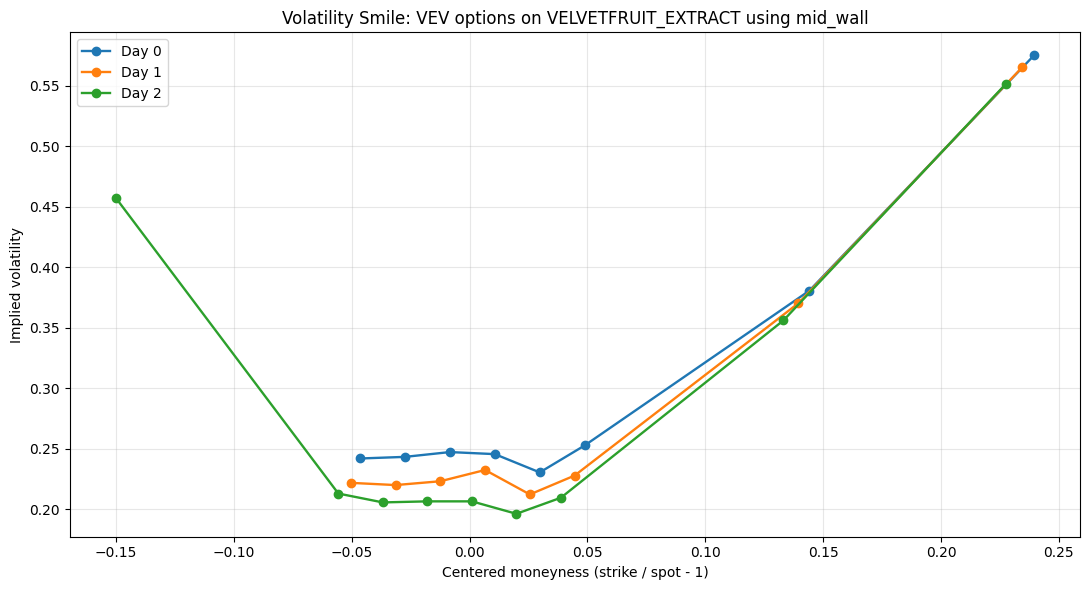

,day,timestamp,product,strike,spot,moneyness,option_price,implied_vol
0,0,999900.0,VEV_5000,5000,5244.0,-0.046529,250.0,0.242028
1,0,999900.0,VEV_5100,5100,5244.0,-0.027460,164.0,0.243363
2,0,999900.0,VEV_5200,5200,5244.0,-0.008391,95.5,0.247330
3,0,999900.0,VEV_5300,5300,5244.0,0.010679,47.0,0.245633
4,0,999900.0,VEV_5400,5400,5244.0,0.029748,16.5,0.230536
5,0,999900.0,VEV_5500,5500,5244.0,0.048818,7.5,0.252804
6,0,999900.0,VEV_6000,6000,5244.0,0.144165,0.5,0.380709
7,0,999900.0,VEV_6500,6500,5244.0,0.239512,0.5,0.575207
8,1,999900.0,VEV_5000,5000,5265.5,-0.050423,268.5,0.221896
9,1,999900.0,VEV_5100,5100,5265.5,-0.031431,177.5,0.220065


In [5]:
from math import erf, exp, log, sqrt
import re

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def norm_cdf(x: float) -> float:
    return 0.5 * (1.0 + erf(x / sqrt(2.0)))


def bs_call_price(spot: float, strike: float, ttm: float, sigma: float, rate: float = 0.0) -> float:
    if sigma <= 0 or ttm <= 0:
        return max(spot - strike, 0.0)

    vol_sqrt_t = sigma * sqrt(ttm)
    d1 = (log(spot / strike) + (rate + 0.5 * sigma * sigma) * ttm) / vol_sqrt_t
    d2 = d1 - vol_sqrt_t
    return spot * norm_cdf(d1) - strike * exp(-rate * ttm) * norm_cdf(d2)


def implied_vol_call(
    price: float,
    spot: float,
    strike: float,
    ttm: float,
    rate: float = 0.0,
    sigma_low: float = 1e-4,
    sigma_high: float = 5.0,
    tol: float = 1e-6,
    max_iter: int = 200,
    min_time_value: float = 0.25,
):
    """Bracketed implied-vol solver.

    This is more stable than Newton-Raphson for deep ITM contracts, but very small
    time value still makes IV numerically weak, so those are filtered out.
    """
    intrinsic = max(spot - strike * exp(-rate * ttm), 0.0)
    time_value = price - intrinsic
    if time_value < min_time_value:
        return np.nan

    if not (intrinsic <= price <= spot):
        return np.nan

    low = sigma_low
    high = sigma_high
    f_low = bs_call_price(spot, strike, ttm, low, rate) - price
    f_high = bs_call_price(spot, strike, ttm, high, rate) - price

    # Expand the bracket if needed.
    expand_count = 0
    while f_low * f_high > 0 and expand_count < 12:
        high *= 1.5
        f_high = bs_call_price(spot, strike, ttm, high, rate) - price
        expand_count += 1

    if f_low * f_high > 0:
        return np.nan

    for _ in range(max_iter):
        mid = 0.5 * (low + high)
        f_mid = bs_call_price(spot, strike, ttm, mid, rate) - price

        if abs(f_mid) < tol or abs(high - low) < 1e-5:
            return mid

        if f_low * f_mid <= 0:
            high = mid
            f_high = f_mid
        else:
            low = mid
            f_low = f_mid

    return 0.5 * (low + high)


# Keep the full hardcoded ladder so no strikes get omitted.
HARDCODED_OPTION_PRODUCTS = [
    "VEV_4000", "VEV_4500", "VEV_5000", "VEV_5100", "VEV_5200",
    "VEV_5300", "VEV_5400", "VEV_5500", "VEV_6000", "VEV_6500",
]

voucher_re = re.compile(r"^VEV_(\d+)$")
if HARDCODED_OPTION_PRODUCTS:
    option_name_mask = prices["product"].isin(HARDCODED_OPTION_PRODUCTS)
else:
    option_name_mask = prices["product"].str.match(voucher_re, na=False)

option_prices = prices[option_name_mask].copy()
if option_prices.empty:
    raise ValueError("No VEV option rows found. Fill HARDCODED_OPTION_PRODUCTS if needed.")

option_prices["strike"] = pd.to_numeric(
    option_prices["product"].str.extract(r"(\d+)")[0],
    errors="coerce",
)
option_prices = option_prices.dropna(subset=["strike"]).copy()
option_prices = option_prices.rename(columns={"mid_price": "option_price"})

underlying_prices = mid_wall_prices[["day", "timestamp", "mid_wall"]].rename(columns={"mid_wall": "spot"}).copy()
if underlying_prices.empty:
    raise ValueError("No mid_wall rows found for the underlying spot series.")

smile = option_prices.merge(
    underlying_prices,
    on=["day", "timestamp"],
    how="inner",
)
smile["moneyness"] = smile["strike"] / smile["spot"] - 1.0

TTM_YEARS = 7 / 365
RISK_FREE_RATE = 0.0
smile["implied_vol"] = smile.apply(
    lambda row: implied_vol_call(
        price=float(row["option_price"]),
        spot=float(row["spot"]),
        strike=float(row["strike"]),
        ttm=TTM_YEARS,
        rate=RISK_FREE_RATE,
    ),
    axis=1,
)

smile_points = []
for day, day_df in smile.groupby("day"):
    last_timestamp = day_df["timestamp"].max()
    snapshot = day_df[day_df["timestamp"] == last_timestamp].copy()
    snapshot = snapshot.dropna(subset=["implied_vol"]).sort_values("moneyness")
    if not snapshot.empty:
        smile_points.append(snapshot)

if not smile_points:
    raise ValueError("No valid smile points found. Check the option pricing data and TTM assumption.")

smile_snapshot = pd.concat(smile_points, ignore_index=True)

fig, ax = plt.subplots(figsize=(11, 6))
cmap = plt.get_cmap("tab10")
for idx, day in enumerate(sorted(smile_snapshot["day"].unique())):
    day_smile = smile_snapshot[smile_snapshot["day"] == day]
    ax.plot(
        day_smile["moneyness"],
        day_smile["implied_vol"],
        marker="o",
        linewidth=1.7,
        color=cmap(idx % cmap.N),
        label=f"Day {day}",
    )

ax.set_title("Volatility Smile: VEV options on VELVETFRUIT_EXTRACT using mid_wall")
ax.set_xlabel("Centered moneyness (strike / spot - 1)")
ax.set_ylabel("Implied volatility")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

smile_snapshot[["day", "timestamp", "product", "strike", "spot", "moneyness", "option_price", "implied_vol"]].head(10)

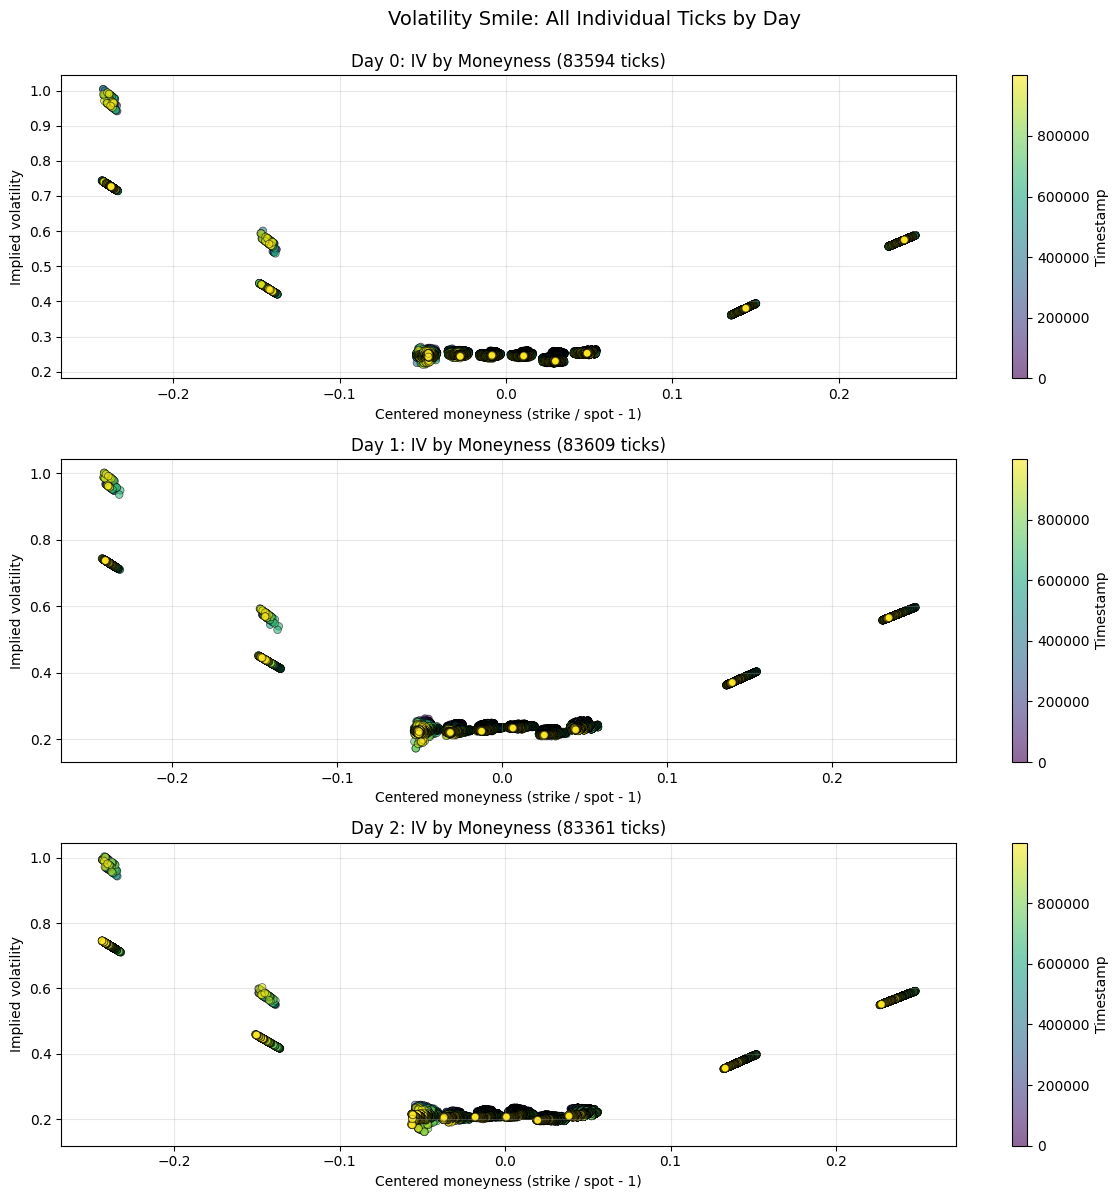

Total ticks plotted: 250564
Ticks per day:
  Day 0: 83594 ticks
  Day 1: 83609 ticks
  Day 2: 83361 ticks


In [6]:
# Detailed plot: every individual tick of implied volatility across all days
smile_clean = smile.dropna(subset=["implied_vol"]).copy()

if smile_clean.empty:
    raise ValueError("No valid smile points found. Check the option pricing data and TTM assumption.")

fig, axes = plt.subplots(len(DAY_LABELS), 1, figsize=(12, 4 * len(DAY_LABELS)))
if len(DAY_LABELS) == 1:
    axes = [axes]

for ax, day in zip(axes, DAY_LABELS):
    day_smile = smile_clean[smile_clean["day"] == day].sort_values(["timestamp", "moneyness"])

    if day_smile.empty:
        ax.text(0.5, 0.5, f"No data for Day {day}", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(f"Day {day}")
        continue

    scatter = ax.scatter(
        day_smile["moneyness"],
        day_smile["implied_vol"],
        c=day_smile["timestamp"],
        s=30,
        alpha=0.6,
        cmap="viridis",
        edgecolors="black",
        linewidth=0.5,
    )

    ax.set_title(f"Day {day}: IV by Moneyness ({len(day_smile)} ticks)")
    ax.set_xlabel("Centered moneyness (strike / spot - 1)")
    ax.set_ylabel("Implied volatility")
    ax.grid(alpha=0.3)

    cbar = plt.colorbar(scatter, ax=ax)
    cbar.set_label("Timestamp")

fig.suptitle("Volatility Smile: All Individual Ticks by Day", fontsize=14, y=0.995)
fig.tight_layout()
plt.show()

print(f"Total ticks plotted: {len(smile_clean)}")
print(f"Ticks per day:")
for day in DAY_LABELS:
    count = len(smile_clean[smile_clean["day"] == day])
    print(f"  Day {day}: {count} ticks")

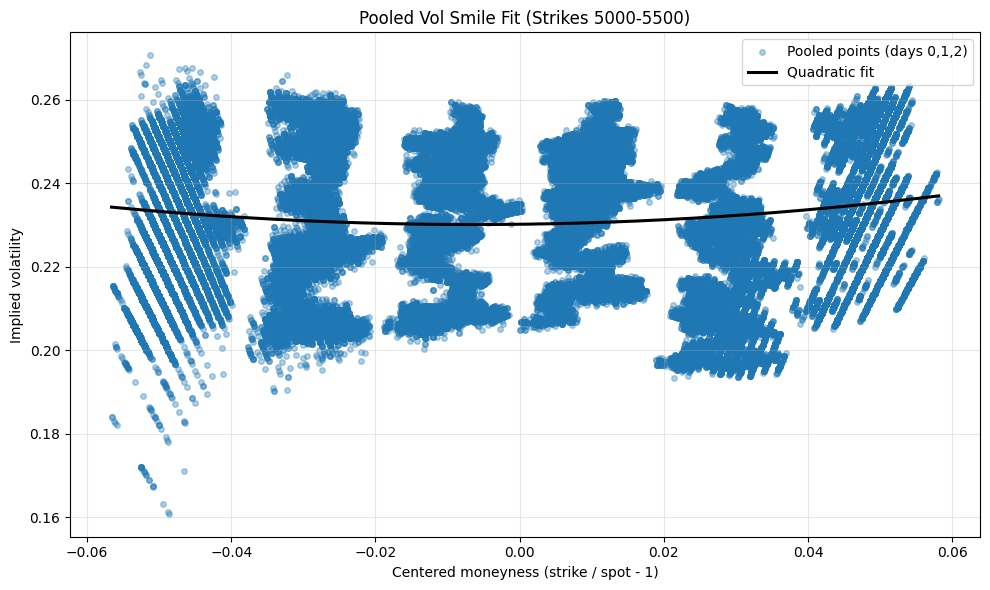

Quadratic coefficients (y = a*x^2 + b*x + c):
a = 1.651954, b = 0.020983, c = 0.230133
Points used: 179988
Strikes included: [5000, 5100, 5200, 5300, 5400, 5500]


In [7]:
# Pooled-days quadratic smile fit for strikes 5000 to 5500
if "smile_clean" in globals():
    pooled_source = smile_clean.copy()
elif "smile" in globals():
    pooled_source = smile.dropna(subset=["implied_vol"]).copy()
else:
    raise ValueError("Run Cell 5 (and Cell 6 if needed) first to create smile data.")

fit_data = pooled_source[
    (pooled_source["strike"] >= 5000) & (pooled_source["strike"] <= 5500)
].dropna(subset=["moneyness", "implied_vol"]).copy()

if len(fit_data) < 3:
    raise ValueError("Need at least 3 points in strikes 5000-5500 for a quadratic fit.")

x = fit_data["moneyness"].to_numpy()
y = fit_data["implied_vol"].to_numpy()

# Quadratic fit: y = a*x^2 + b*x + c
a, b, c = np.polyfit(x, y, 2)

x_line = np.linspace(x.min(), x.max(), 300)
y_line = a * x_line**2 + b * x_line + c

fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x, y, s=16, alpha=0.35, label="Pooled points (days 0,1,2)")
ax.plot(x_line, y_line, color="black", linewidth=2.2, label="Quadratic fit")

ax.set_title("Pooled Vol Smile Fit (Strikes 5000-5500)")
ax.set_xlabel("Centered moneyness (strike / spot - 1)")
ax.set_ylabel("Implied volatility")
ax.grid(alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

print("Quadratic coefficients (y = a*x^2 + b*x + c):")
print(f"a = {a:.6f}, b = {b:.6f}, c = {c:.6f}")
print(f"Points used: {len(fit_data)}")
print("Strikes included:", sorted(fit_data["strike"].dropna().unique().tolist()))

2D VOLATILITY SMILE FIT: IV = f(moneyness, TTE)

Fit using 179988 data points
Moneyness range: [-0.0566, 0.0581]
TTE range: [0.013699, 0.019178] years
R² score: 0.736678

INTERCEPT:
  a₀ (const) = 0.28964286

LINEAR TERMS:
  moneyness       =   0.00000000
  tte             =  -0.18548491
  moneyness tte   =   1.70027269

QUADRATIC & INTERACTION TERMS:
  moneyness^2     =  -0.90852937
  moneyness tte   =   1.70027269
  tte^2           =  12.00763347

RMSE: 0.00842615


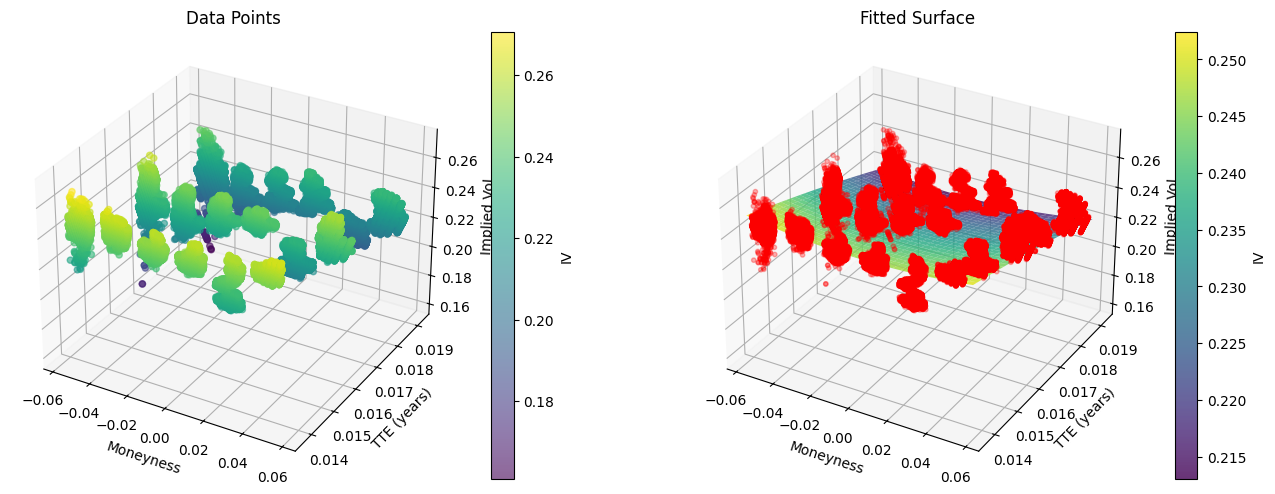

In [8]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings("ignore")

if "smile_clean" in globals():
    fit_source = smile_clean.copy()
elif "smile" in globals():
    fit_source = smile.dropna(subset=["implied_vol"]).copy()
else:
    raise ValueError("Run earlier cells first to create smile data.")

min_day = fit_source["day"].min()
max_day = fit_source["day"].max()
reference_day = max_day

fit_source["tte_years"] = (fit_source["day"] - reference_day) * (1 / 365) + TTM_YEARS

fit_data_2d = fit_source[
    (fit_source["strike"] >= 5000) & (fit_source["strike"] <= 5500)
].dropna(subset=["moneyness", "implied_vol", "tte_years"]).copy()

if len(fit_data_2d) < 6:
    raise ValueError("Need at least 6 points for 2D polynomial fit.")

X = fit_data_2d[["moneyness", "tte_years"]].to_numpy()
y = fit_data_2d["implied_vol"].to_numpy()

poly = PolynomialFeatures(degree=2, include_bias=True)
X_poly = poly.fit_transform(X)
model = LinearRegression().fit(X_poly, y)

feature_names = poly.get_feature_names_out(["moneyness", "tte"])
coeffs = model.coef_

print("=" * 70)
print("2D VOLATILITY SMILE FIT: IV = f(moneyness, TTE)")
print("=" * 70)
print(f"\nFit using {len(fit_data_2d)} data points")
print(f"Moneyness range: [{fit_data_2d['moneyness'].min():.4f}, {fit_data_2d['moneyness'].max():.4f}]")
print(f"TTE range: [{fit_data_2d['tte_years'].min():.6f}, {fit_data_2d['tte_years'].max():.6f}] years")
print(f"R² score: {model.score(X_poly, y):.6f}\n")

print("INTERCEPT:")
print(f"  a₀ (const) = {model.intercept_:.8f}\n")

print("LINEAR TERMS:")
for i, fname in enumerate(feature_names[1:]):
    if "^" not in fname:
        print(f"  {fname:15s} = {coeffs[i]:12.8f}")

print("\nQUADRATIC & INTERACTION TERMS:")
for i, fname in enumerate(feature_names[1:]):
    if "^" in fname or " " in fname:
        print(f"  {fname:15s} = {coeffs[i]:12.8f}")

y_pred = model.predict(X_poly)
rmse = np.sqrt(np.mean((y - y_pred) ** 2))
print(f"\nRMSE: {rmse:.8f}")

fig = plt.figure(figsize=(14, 5))

ax1 = fig.add_subplot(121, projection="3d")
scatter = ax1.scatter(
    fit_data_2d["moneyness"],
    fit_data_2d["tte_years"],
    fit_data_2d["implied_vol"],
    c=fit_data_2d["implied_vol"],
    cmap="viridis",
    s=20,
    alpha=0.6,
)
ax1.set_xlabel("Moneyness")
ax1.set_ylabel("TTE (years)")
ax1.set_zlabel("Implied Vol")
ax1.set_title("Data Points")
plt.colorbar(scatter, ax=ax1, label="IV")

ax2 = fig.add_subplot(122, projection="3d")
m_range = np.linspace(fit_data_2d["moneyness"].min(), fit_data_2d["moneyness"].max(), 30)
t_range = np.linspace(fit_data_2d["tte_years"].min(), fit_data_2d["tte_years"].max(), 30)
M, T = np.meshgrid(m_range, t_range)
X_surface = np.column_stack([M.ravel(), T.ravel()])
X_surface_poly = poly.transform(X_surface)
Z = model.predict(X_surface_poly).reshape(M.shape)

surf = ax2.plot_surface(M, T, Z, cmap="viridis", alpha=0.8, edgecolor="none")
ax2.scatter(
    fit_data_2d["moneyness"],
    fit_data_2d["tte_years"],
    fit_data_2d["implied_vol"],
    color="red",
    s=10,
    alpha=0.3,
)
ax2.set_xlabel("Moneyness")
ax2.set_ylabel("TTE (years)")
ax2.set_zlabel("Implied Vol")
ax2.set_title("Fitted Surface")
plt.colorbar(surf, ax=ax2, label="IV")

fig.tight_layout()
plt.show()

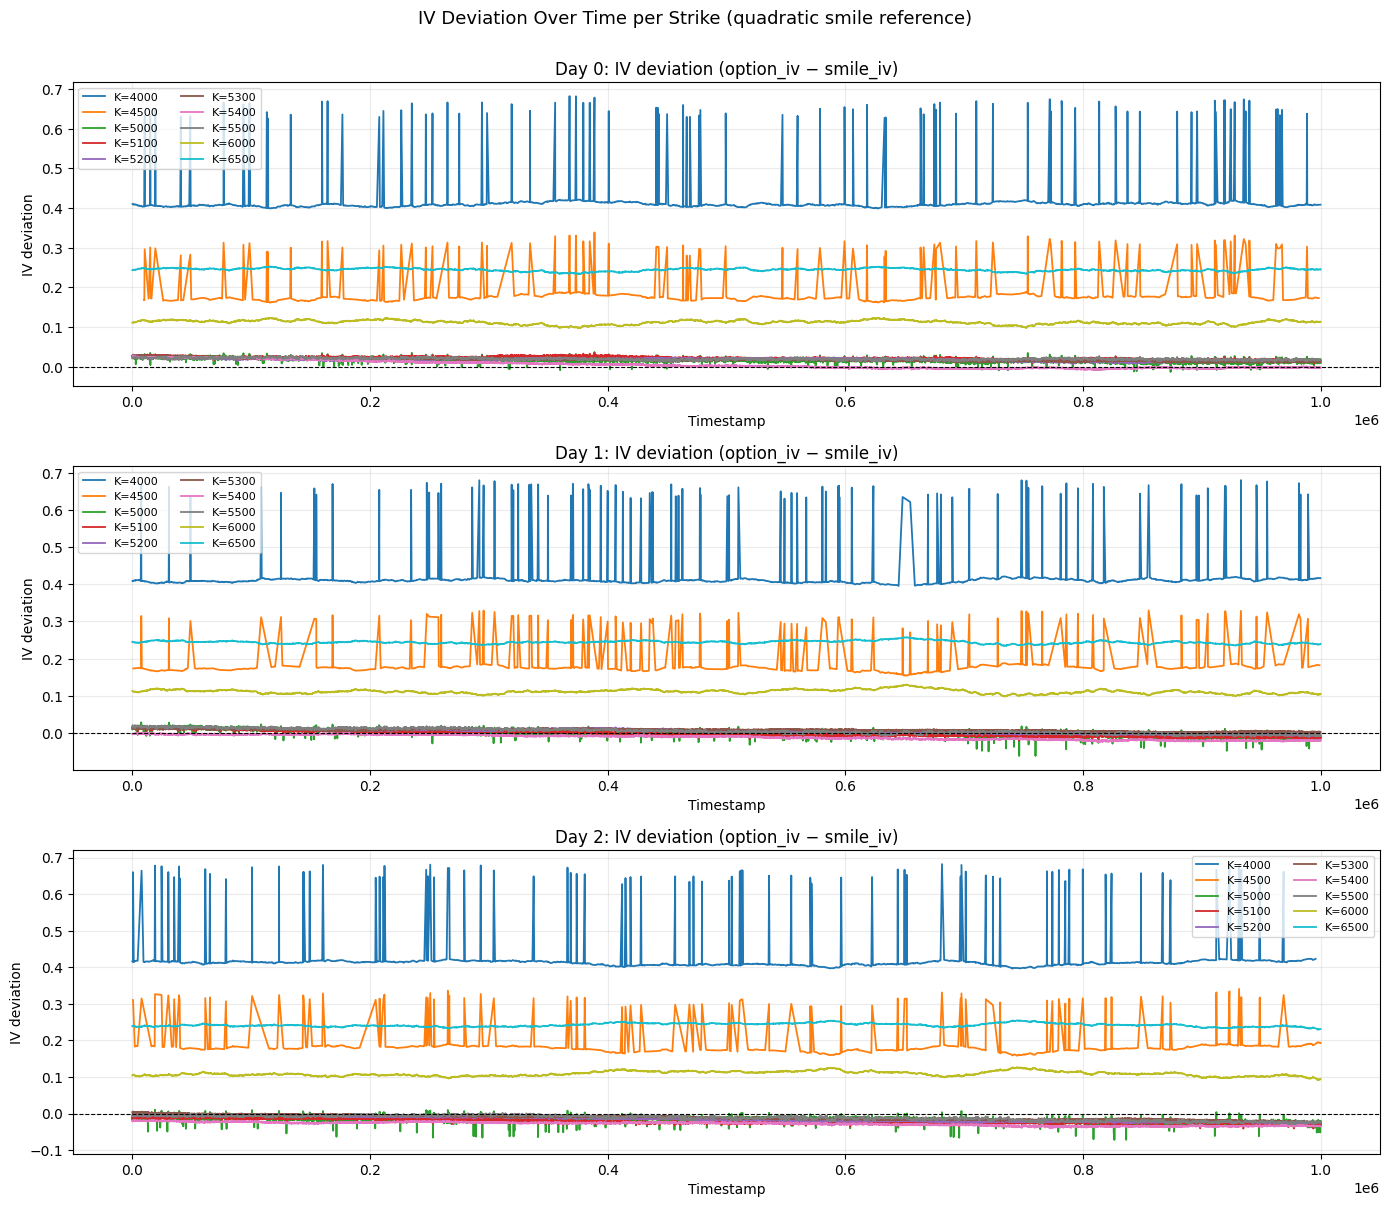

In [9]:
# IV deviation over time: option_iv - volsmile_iv
# Requires 'a, b, c' from the quadratic fit cell and 'smile_clean' from earlier cells.

dev_df = smile_clean.copy()
dev_df["volsmile_iv"] = np.polyval([a, b, c], dev_df["moneyness"])
dev_df["iv_deviation"] = dev_df["implied_vol"] - dev_df["volsmile_iv"]

strikes = sorted(dev_df["strike"].dropna().unique())
cmap = plt.get_cmap("tab10")
strike_colors = {s: cmap(i % cmap.N) for i, s in enumerate(strikes)}

fig, axes = plt.subplots(len(DAY_LABELS), 1, figsize=(14, 4 * len(DAY_LABELS)), sharex=False)
if len(DAY_LABELS) == 1:
    axes = [axes]

for ax, day in zip(axes, DAY_LABELS):
    day_df = dev_df[dev_df["day"] == day].sort_values("timestamp")
    if day_df.empty:
        ax.set_title(f"Day {day} — no data")
        continue

    for strike in strikes:
        s_df = day_df[day_df["strike"] == strike]
        if s_df.empty:
            continue
        ax.plot(
            s_df["timestamp"],
            s_df["iv_deviation"],
            linewidth=1.3,
            color=strike_colors[strike],
            label=f"K={int(strike)}",
        )

    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_title(f"Day {day}: IV deviation (option_iv − smile_iv)")
    ax.set_ylabel("IV deviation")
    ax.set_xlabel("Timestamp")
    ax.grid(alpha=0.25)
    ax.legend(loc="best", fontsize=8, ncol=2)

fig.suptitle("IV Deviation Over Time per Strike (quadratic smile reference)", fontsize=13, y=1.002)
fig.tight_layout()
plt.show()


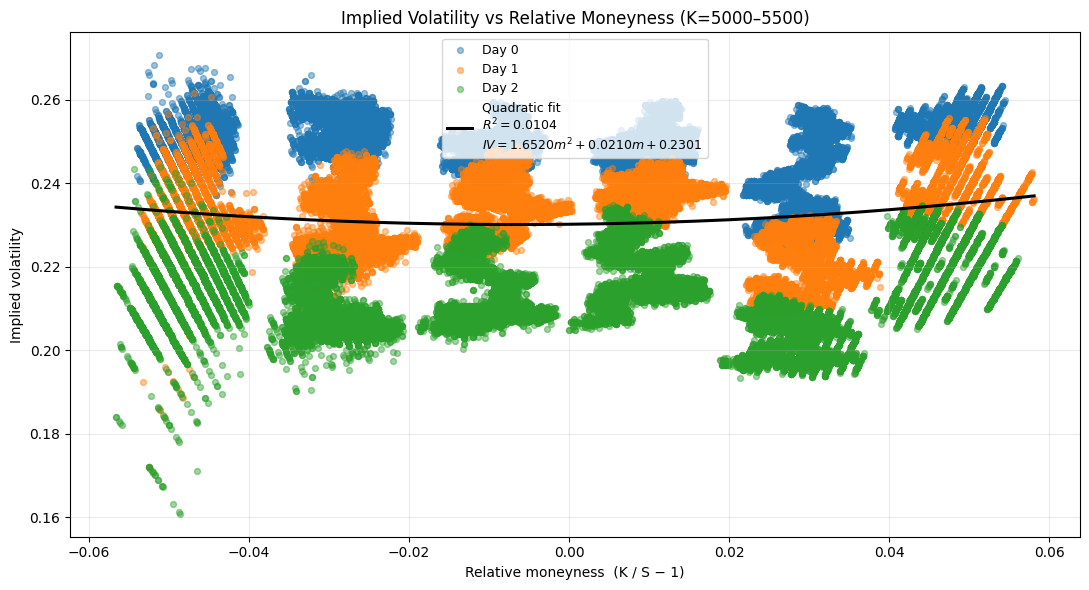

In [10]:
# IV vs relative moneyness with quadratic fit — strikes 5000–5500

fit_df = smile_clean[
    (smile_clean["strike"] >= 5000) & (smile_clean["strike"] <= 5500)
].dropna(subset=["moneyness", "implied_vol"]).copy()

x = fit_df["moneyness"].to_numpy()
y = fit_df["implied_vol"].to_numpy()

qa, qb, qc = np.polyfit(x, y, 2)
r2 = 1 - np.sum((y - np.polyval([qa, qb, qc], x)) ** 2) / np.sum((y - y.mean()) ** 2)

x_line = np.linspace(x.min(), x.max(), 400)
y_line = np.polyval([qa, qb, qc], x_line)

days = sorted(fit_df["day"].unique())
cmap = plt.get_cmap("tab10")

fig, ax = plt.subplots(figsize=(11, 6))

for i, day in enumerate(days):
    d = fit_df[fit_df["day"] == day]
    ax.scatter(
        d["moneyness"], d["implied_vol"],
        s=18, alpha=0.45, color=cmap(i % cmap.N), label=f"Day {day}",
    )

ax.plot(x_line, y_line, color="black", linewidth=2.2,
        label=f"Quadratic fit\n$R^2={r2:.4f}$\n$IV = {qa:.4f}m^2 {qb:+.4f}m {qc:+.4f}$")

ax.set_title("Implied Volatility vs Relative Moneyness (K=5000–5500)")
ax.set_xlabel("Relative moneyness  (K / S − 1)")
ax.set_ylabel("Implied volatility")
ax.grid(alpha=0.25)
ax.legend(loc="upper center", fontsize=9)
fig.tight_layout()
plt.show()


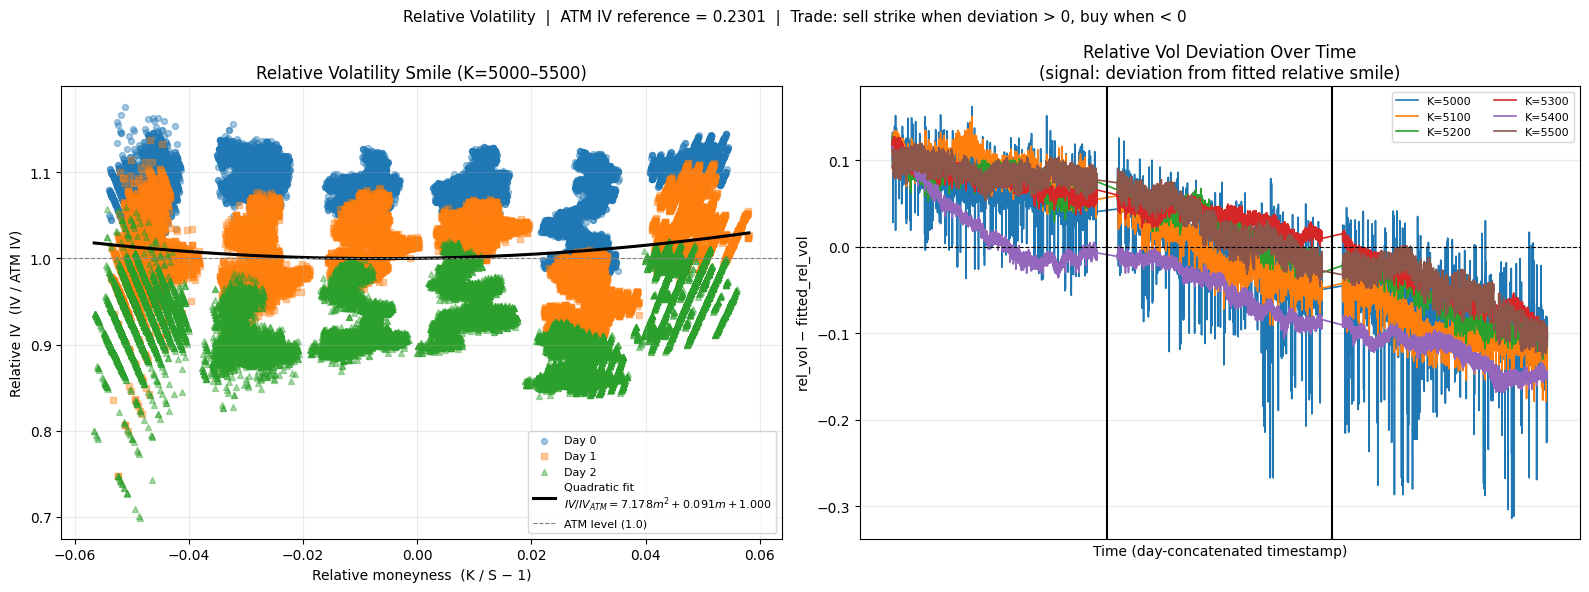

ATM IV reference (qc): 0.230133
Relative smile fit: rv = 7.178248·m² +0.091176·m +1.000000


In [11]:
# Relative volatility: IV / ATM_IV, where ATM_IV = smile fit at moneyness=0 (= qc)
# Uses qa, qb, qc from the quadratic fit cell above.

rv_df = smile_clean[
    (smile_clean["strike"] >= 5000) & (smile_clean["strike"] <= 5500)
].dropna(subset=["moneyness", "implied_vol"]).copy()

atm_iv = qc  # quadratic fit value at m=0
rv_df["rel_vol"] = rv_df["implied_vol"] / atm_iv

# Fit a quadratic to the relative smile
x_rv = rv_df["moneyness"].to_numpy()
y_rv = rv_df["rel_vol"].to_numpy()
ra, rb, rc = np.polyfit(x_rv, y_rv, 2)

x_line_rv = np.linspace(x_rv.min(), x_rv.max(), 400)
y_line_rv = np.polyval([ra, rb, rc], x_line_rv)

# Per-strike: rel vol deviation from the fitted relative smile
rv_df["fitted_rel_vol"] = np.polyval([ra, rb, rc], rv_df["moneyness"])
rv_df["rel_vol_dev"] = rv_df["rel_vol"] - rv_df["fitted_rel_vol"]

strikes_rv = sorted(rv_df["strike"].unique())
days_rv = sorted(rv_df["day"].unique())
cmap = plt.get_cmap("tab10")
strike_colors = {s: cmap(i % cmap.N) for i, s in enumerate(strikes_rv)}
day_markers = {d: m for d, m in zip(days_rv, ["o", "s", "^", "D", "v"])}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Left: relative smile ---
ax = axes[0]
for i, day in enumerate(days_rv):
    d = rv_df[rv_df["day"] == day]
    ax.scatter(d["moneyness"], d["rel_vol"],
               s=18, alpha=0.4, color=cmap(i % cmap.N),
               marker=day_markers.get(day, "o"), label=f"Day {day}")

ax.plot(x_line_rv, y_line_rv, color="black", linewidth=2.2,
        label=f"Quadratic fit\n$IV/IV_{{ATM}} = {ra:.3f}m^2{rb:+.3f}m{rc:+.3f}$")
ax.axhline(1.0, color="gray", linewidth=0.8, linestyle="--", label="ATM level (1.0)")
ax.set_title("Relative Volatility Smile (K=5000–5500)")
ax.set_xlabel("Relative moneyness  (K / S − 1)")
ax.set_ylabel("Relative IV  (IV / ATM IV)")
ax.grid(alpha=0.25)
ax.legend(fontsize=8)

# --- Right: relative vol deviation over time per strike ---
ax = axes[1]
for strike in strikes_rv:
    s_df = rv_df[rv_df["strike"] == strike].sort_values(["day", "timestamp"])
    # Build a continuous x: day * large_offset + timestamp
    s_df = s_df.copy()
    s_df["x"] = s_df["day"] * 1_100_000 + s_df["timestamp"]
    ax.plot(s_df["x"], s_df["rel_vol_dev"],
            linewidth=1.2, color=strike_colors[strike], label=f"K={int(strike)}")

# Day separators
for day in days_rv[:-1]:
    sep = day * 1_100_000 + rv_df[rv_df["day"] == day]["timestamp"].max() + 50_000
    ax.axvline(sep, color="black", linewidth=1.5)

ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
ax.set_title("Relative Vol Deviation Over Time\n(signal: deviation from fitted relative smile)")
ax.set_xlabel("Time (day-concatenated timestamp)")
ax.set_ylabel("rel_vol − fitted_rel_vol")
ax.grid(alpha=0.25)
ax.legend(fontsize=8, ncol=2)
ax.set_xticks([])

fig.suptitle(
    f"Relative Volatility  |  ATM IV reference = {atm_iv:.4f}  |  "
    f"Trade: sell strike when deviation > 0, buy when < 0",
    fontsize=11,
)
fig.tight_layout()
plt.show()

print(f"ATM IV reference (qc): {atm_iv:.6f}")
print(f"Relative smile fit: rv = {ra:.6f}·m² {rb:+.6f}·m {rc:+.6f}")


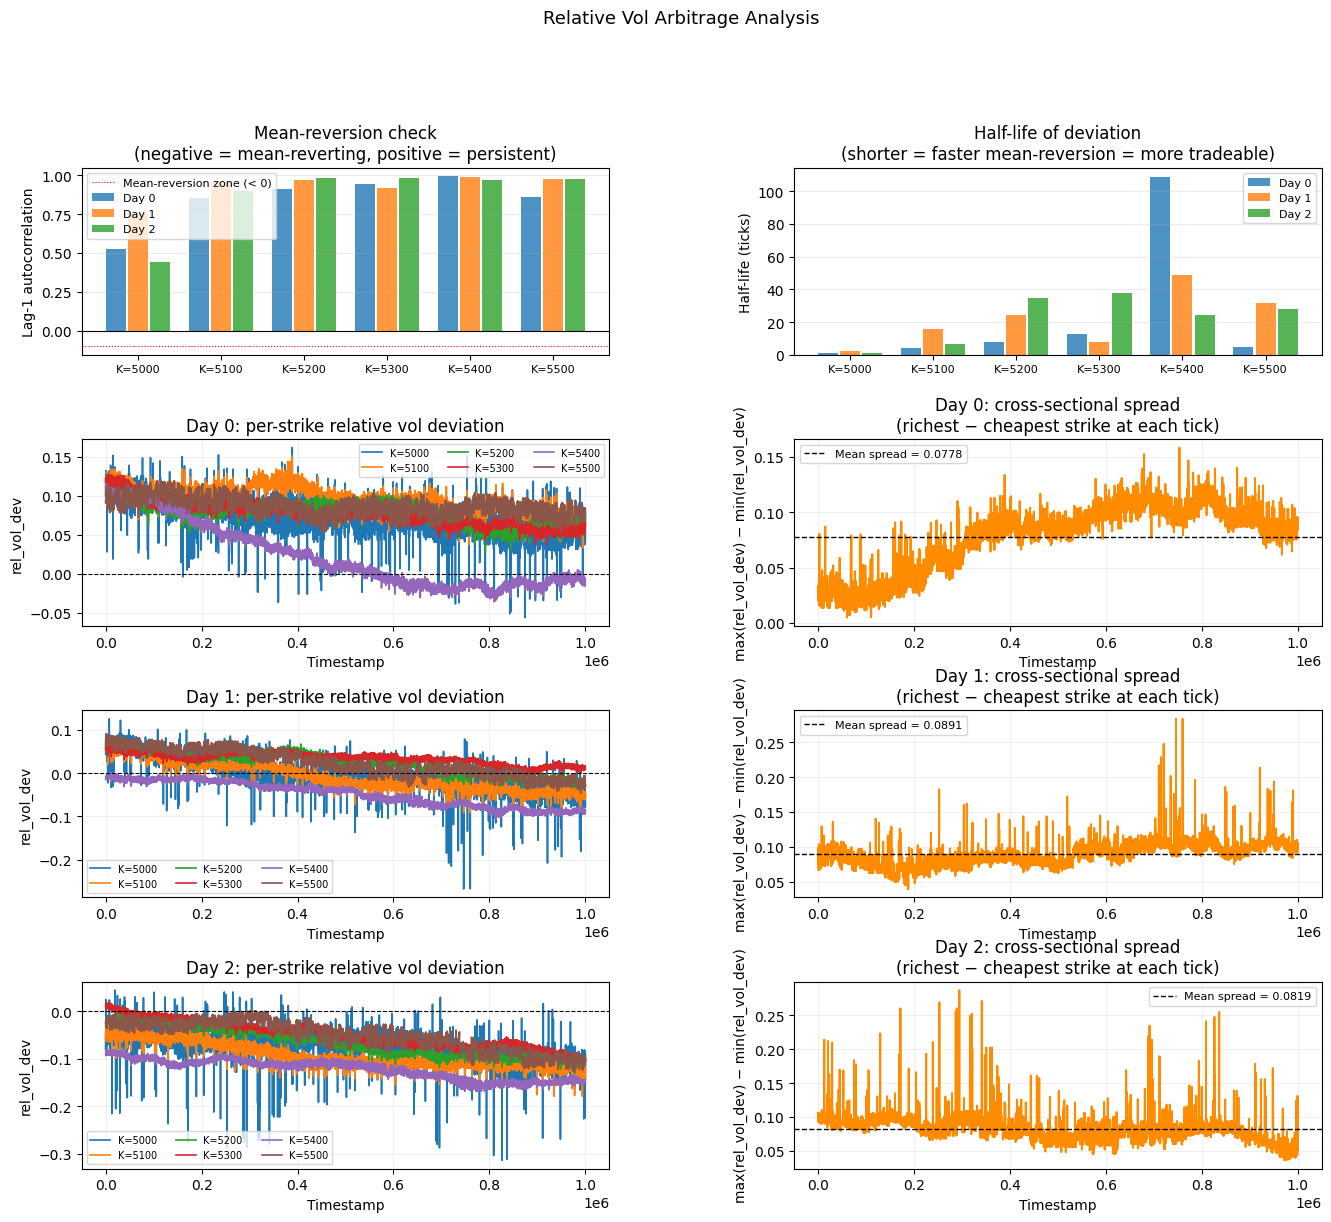

Lag-1 autocorrelation and half-lives:
 day  strike  lag1_acf  half_life_ticks
   0    5000  0.522614         1.068169
   0    5100  0.850639         4.284826
   0    5200  0.912587         7.577747
   0    5300  0.946667        12.646810
   0    5400  0.993662       109.011862
   0    5500  0.863157         4.710213
   1    5000  0.757034         2.490226
   1    5100  0.957235        15.859009
   1    5200  0.971634        24.087337
   1    5300  0.915122         7.814728
   1    5400  0.985933        48.929015
   1    5500  0.978219        31.476185
   2    5000  0.443525         0.852579
   2    5100  0.901438         6.680012
   2    5200  0.980333        34.895762
   2    5300  0.981898        37.943090
   2    5400  0.972134        24.526289
   2    5500  0.975461        27.899141

Cross-sectional spread stats (rel_vol units):
  Day 0: mean=0.0778  std=0.0300  max=0.1586
  Day 1: mean=0.0891  std=0.0148  max=0.2837
  Day 2: mean=0.0819  std=0.0169  max=0.2873


In [14]:
# Mean-reversion test + cross-sectional spread analysis

# ── Lag-1 autocorrelation per strike per day ──────────────────────────────────
autocorr_records = []
for day in days_rv:
    for strike in strikes_rv:
        s = (rv_df[(rv_df["day"] == day) & (rv_df["strike"] == strike)]
             .sort_values("timestamp")["rel_vol_dev"]
             .dropna().to_numpy())
        if len(s) < 10:
            continue
        rho = float(np.corrcoef(s[:-1], s[1:])[0, 1])
        half_life = -np.log(2) / np.log(abs(rho)) if 0 < abs(rho) < 1 else np.nan
        autocorr_records.append({"day": day, "strike": int(strike), "lag1_acf": rho, "half_life_ticks": half_life})

acf_df = pd.DataFrame(autocorr_records)

# ── Cross-sectional spread pivot ───────────────────────────────────────────────
pivot = (rv_df.pivot_table(index=["day", "timestamp"], columns="strike", values="rel_vol_dev")
         .sort_index())
pivot.columns = [int(c) for c in pivot.columns]
pivot["xsect_spread"] = pivot.max(axis=1) - pivot.min(axis=1)  # richest − cheapest

# ── Figure ─────────────────────────────────────────────────────────────────────
n_days = len(days_rv)
fig = plt.figure(figsize=(16, 4 + 3 * n_days))
gs = fig.add_gridspec(1 + n_days, 2, hspace=0.45, wspace=0.35)

# Top-left: lag-1 autocorrelation grouped bar
ax_acf = fig.add_subplot(gs[0, 0])
bar_width = 0.8 / max(n_days, 1)
for i, day in enumerate(days_rv):
    day_acf = acf_df[acf_df["day"] == day].sort_values("strike")
    x_pos = np.arange(len(day_acf["strike"])) + i * bar_width
    bars = ax_acf.bar(x_pos, day_acf["lag1_acf"], width=bar_width * 0.9,
                      color=cmap(i % cmap.N), alpha=0.8, label=f"Day {day}")

ax_acf.axhline(0, color="black", linewidth=0.8)
ax_acf.axhline(-0.1, color="red", linewidth=0.8, linestyle=":", label="Mean-reversion zone (< 0)")
tick_centers = np.arange(len(strikes_rv)) + bar_width * (n_days - 1) / 2
ax_acf.set_xticks(tick_centers)
ax_acf.set_xticklabels([f"K={s}" for s in strikes_rv], fontsize=8)
ax_acf.set_ylabel("Lag-1 autocorrelation")
ax_acf.set_title("Mean-reversion check\n(negative = mean-reverting, positive = persistent)")
ax_acf.legend(fontsize=8)
ax_acf.grid(axis="y", alpha=0.25)

# Top-right: half-life summary
ax_hl = fig.add_subplot(gs[0, 1])
for i, day in enumerate(days_rv):
    day_acf = acf_df[acf_df["day"] == day].sort_values("strike")
    x_pos = np.arange(len(day_acf["strike"])) + i * bar_width
    ax_hl.bar(x_pos, day_acf["half_life_ticks"], width=bar_width * 0.9,
              color=cmap(i % cmap.N), alpha=0.8, label=f"Day {day}")

ax_hl.set_xticks(tick_centers)
ax_hl.set_xticklabels([f"K={s}" for s in strikes_rv], fontsize=8)
ax_hl.set_ylabel("Half-life (ticks)")
ax_hl.set_title("Half-life of deviation\n(shorter = faster mean-reversion = more tradeable)")
ax_hl.legend(fontsize=8)
ax_hl.grid(axis="y", alpha=0.25)

# Per-day rows: cross-sectional spread + per-strike deviations
for row_i, day in enumerate(days_rv):
    day_pivot = pivot.loc[day].copy() if day in pivot.index.get_level_values("day") else pd.DataFrame()

    # Left: per-strike rel_vol_dev (heatmap-style lines)
    ax_l = fig.add_subplot(gs[1 + row_i, 0])
    for strike in strikes_rv:
        if strike not in day_pivot.columns:
            continue
        ax_l.plot(day_pivot.index, day_pivot[strike],
                  color=strike_colors[strike], linewidth=1.2, label=f"K={strike}")
    ax_l.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax_l.set_title(f"Day {day}: per-strike relative vol deviation")
    ax_l.set_xlabel("Timestamp")
    ax_l.set_ylabel("rel_vol_dev")
    ax_l.grid(alpha=0.2)
    ax_l.legend(fontsize=7, ncol=3)

    # Right: cross-sectional spread (max − min) = size of the tradeable gap
    ax_r = fig.add_subplot(gs[1 + row_i, 1])
    if not day_pivot.empty and "xsect_spread" in day_pivot.columns:
        ax_r.plot(day_pivot.index, day_pivot["xsect_spread"],
                  color="darkorange", linewidth=1.4)
        ax_r.axhline(day_pivot["xsect_spread"].mean(), color="black",
                     linewidth=1, linestyle="--", label=f"Mean spread = {day_pivot['xsect_spread'].mean():.4f}")
    ax_r.set_title(f"Day {day}: cross-sectional spread\n(richest − cheapest strike at each tick)")
    ax_r.set_xlabel("Timestamp")
    ax_r.set_ylabel("max(rel_vol_dev) − min(rel_vol_dev)")
    ax_r.grid(alpha=0.2)
    ax_r.legend(fontsize=8)

fig.suptitle("Relative Vol Arbitrage Analysis", fontsize=13, y=1.002)
plt.show()

# ── Summary ───────────────────────────────────────────────────────────────────
print("Lag-1 autocorrelation and half-lives:")
print(acf_df.to_string(index=False))
print()
print("Cross-sectional spread stats (rel_vol units):")
for day in days_rv:
    if day in pivot.index.get_level_values("day"):
        sp = pivot.loc[day, "xsect_spread"].dropna()
        print(f"  Day {day}: mean={sp.mean():.4f}  std={sp.std():.4f}  max={sp.max():.4f}")


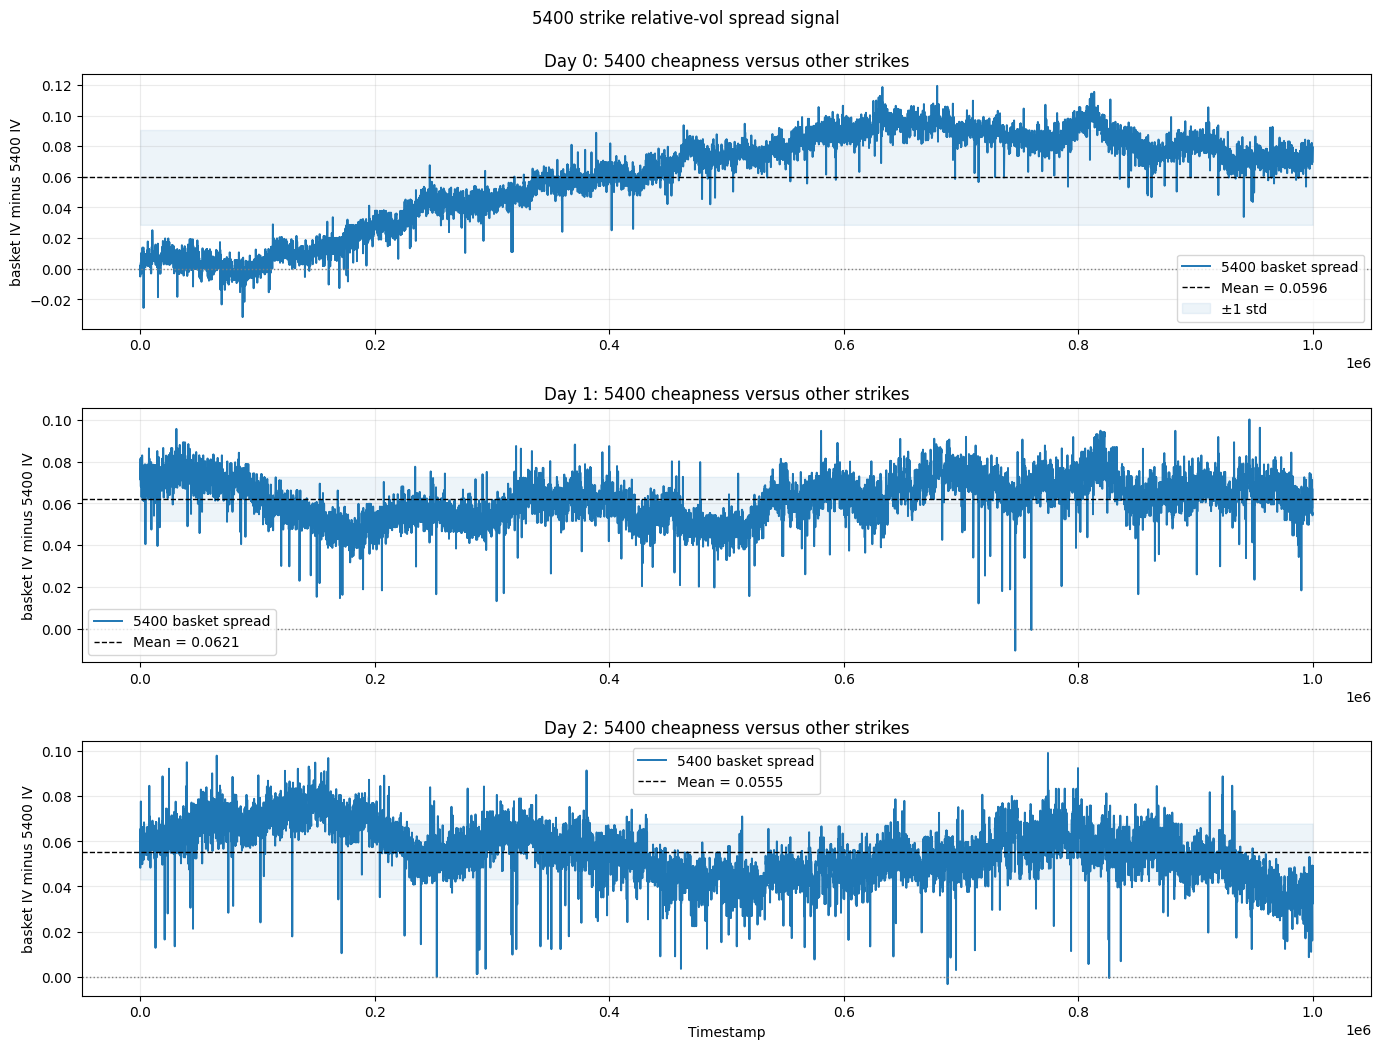

5400 vs basket spread summary
 day  mean_spread  std_spread  min_spread  max_spread  lag1_acf  half_life_ticks      p10      p50      p90
   0     0.059587    0.030951   -0.031615    0.119340  0.973074        25.394439 0.007559 0.069769 0.092638
   1     0.062145    0.010541   -0.010583    0.100209  0.677521         1.780428 0.048454 0.062336 0.075469
   2     0.055451    0.012417   -0.003337    0.099142  0.700244         1.945263 0.039975 0.055367 0.071352

Signal counts by day
trade_signal  buy_5400_short_basket  flat  sell_5400_long_basket
day                                                             
0                              1391  6521                   2088
1                              1606  6757                   1637
2                              1673  6839                   1488


In [15]:
# 5400 strike versus the rest of the smile basket
# Positive spread means 5400 is cheap relative to the average of the other strikes.

if 'rv_df' not in globals():
    raise ValueError("Run the relative-vol analysis cells first to create rv_df.")

target_strike = 5400
other_strikes = [strike for strike in strikes_rv if strike != target_strike]

spread_frames = []
for day in days_rv:
    day_slice = rv_df[rv_df['day'] == day].copy()
    if day_slice.empty:
        continue

    pivot_day = day_slice.pivot_table(index='timestamp', columns='strike', values='rel_vol_dev').sort_index()
    if target_strike not in pivot_day.columns:
        continue

    basket_cols = [strike for strike in other_strikes if strike in pivot_day.columns]
    if not basket_cols:
        continue

    spread = pivot_day[basket_cols].mean(axis=1) - pivot_day[target_strike]
    spread = spread.dropna().rename('spread')
    if spread.empty:
        continue

    day_stats = pd.DataFrame({
        'day': day,
        'timestamp': spread.index.astype(float),
        'spread': spread.to_numpy(),
    })
    day_stats['zscore'] = (day_stats['spread'] - day_stats['spread'].mean()) / day_stats['spread'].std(ddof=0)
    spread_frames.append(day_stats)

if not spread_frames:
    raise ValueError("Could not build a 5400-vs-basket spread from the available smile data.")

spread_df = pd.concat(spread_frames, ignore_index=True)

summary_rows = []
for day, day_df in spread_df.groupby('day'):
    values = day_df['spread'].to_numpy()
    rho = float(np.corrcoef(values[:-1], values[1:])[0, 1]) if len(values) > 2 else np.nan
    half_life = -np.log(2) / np.log(abs(rho)) if 0 < abs(rho) < 1 else np.nan
    summary_rows.append({
        'day': int(day),
        'mean_spread': float(np.mean(values)),
        'std_spread': float(np.std(values, ddof=0)),
        'min_spread': float(np.min(values)),
        'max_spread': float(np.max(values)),
        'lag1_acf': rho,
        'half_life_ticks': half_life,
        'p10': float(np.quantile(values, 0.10)),
        'p50': float(np.quantile(values, 0.50)),
        'p90': float(np.quantile(values, 0.90)),
    })

summary_df = pd.DataFrame(summary_rows).sort_values('day')

fig, axes = plt.subplots(len(days_rv), 1, figsize=(14, 3.5 * len(days_rv)), sharex=False)
if len(days_rv) == 1:
    axes = [axes]

for ax, day in zip(axes, days_rv):
    day_df = spread_df[spread_df['day'] == day].sort_values('timestamp')
    if day_df.empty:
        continue

    ax.plot(day_df['timestamp'], day_df['spread'], color='tab:blue', linewidth=1.4, label='5400 basket spread')
    ax.axhline(day_df['spread'].mean(), color='black', linestyle='--', linewidth=1, label=f"Mean = {day_df['spread'].mean():.4f}")
    ax.axhline(0, color='gray', linestyle=':', linewidth=1)

    upper = day_df['spread'].mean() + day_df['spread'].std(ddof=0)
    lower = day_df['spread'].mean() - day_df['spread'].std(ddof=0)
    ax.fill_between(day_df['timestamp'], lower, upper, color='tab:blue', alpha=0.08, label='±1 std' if day == days_rv[0] else None)

    ax.set_title(f"Day {day}: 5400 cheapness versus other strikes")
    ax.set_ylabel('basket IV minus 5400 IV')
    ax.grid(alpha=0.25)
    ax.legend(loc='best')

axes[-1].set_xlabel('Timestamp')
fig.suptitle('5400 strike relative-vol spread signal', y=0.995)
fig.tight_layout()
plt.show()

print('5400 vs basket spread summary')
print(summary_df.to_string(index=False))

current = spread_df.copy()
current['trade_signal'] = np.where(current['zscore'] > 1.0, 'buy_5400_short_basket', np.where(current['zscore'] < -1.0, 'sell_5400_long_basket', 'flat'))
print()
print('Signal counts by day')
print(current.groupby(['day', 'trade_signal']).size().unstack(fill_value=0).to_string())

In [20]:
# Alpha strategy sweep (options): rank candidate signals by gross and net performance
import numpy as np
import pandas as pd

if 'rv_df' not in globals():
    raise ValueError("rv_df is missing. Run prior smile cells first.")

scan = rv_df[["day", "timestamp", "strike", "option_price", "rel_vol_dev", "moneyness", "implied_vol"]].copy()
scan = scan.sort_values(["day", "strike", "timestamp"]).reset_index(drop=True)
scan["next_option_price"] = scan.groupby(["day", "strike"])["option_price"].shift(-1)
scan["fwd_ret"] = scan["next_option_price"] - scan["option_price"]
scan = scan.dropna(subset=["fwd_ret"]).copy()

if scan.empty:
    raise ValueError("No forward returns found after preprocessing.")

# Build cross-sectional and 5400-specific features.
scan["xsec_dev"] = scan["rel_vol_dev"] - scan.groupby(["day", "timestamp"])["rel_vol_dev"].transform("mean")

pivot = scan.pivot_table(index=["day", "timestamp"], columns="strike", values="rel_vol_dev").sort_index()
if 5400 in pivot.columns:
    other_cols = [col for col in pivot.columns if col != 5400]
    if other_cols:
        spread_5400 = (pivot[other_cols].mean(axis=1) - pivot[5400]).rename("spread_5400")
        scan = scan.merge(
            spread_5400.reset_index(),
            on=["day", "timestamp"],
            how="left",
        )
    else:
        scan["spread_5400"] = np.nan
else:
    scan["spread_5400"] = np.nan


def zscore_by_group(series: pd.Series, group: pd.Series) -> pd.Series:
    grp = series.groupby(group)
    mu = grp.transform("mean")
    sd = grp.transform("std").replace(0, np.nan)
    return (series - mu) / sd


def evaluate_strategy(df: pd.DataFrame, signal: pd.Series, name: str, mask: pd.Series | None = None, cost_per_turnover: float = 0.15) -> dict:
    tmp = df.copy()
    tmp["signal_raw"] = signal

    if mask is None:
        mask = pd.Series(True, index=tmp.index)
    tmp = tmp[mask].copy()

    tmp = tmp.dropna(subset=["signal_raw", "fwd_ret"]).copy()
    if tmp.empty:
        return {
            "strategy": name,
            "rows": 0,
            "gross_pnl": np.nan,
            "net_pnl": np.nan,
            "gross_sharpe": np.nan,
            "net_sharpe": np.nan,
            "hit_rate": np.nan,
            "avg_turnover": np.nan,
        }

    tmp["signal_z"] = zscore_by_group(tmp["signal_raw"], [tmp["day"], tmp["strike"]]).clip(-3, 3)
    tmp["position"] = tmp["signal_z"].fillna(0)

    tmp = tmp.sort_values(["day", "strike", "timestamp"]).copy()
    tmp["prev_position"] = tmp.groupby(["day", "strike"])["position"].shift(1).fillna(0)
    tmp["turnover"] = (tmp["position"] - tmp["prev_position"]).abs()

    tmp["gross_pnl_tick"] = tmp["position"] * tmp["fwd_ret"]
    tmp["net_pnl_tick"] = tmp["gross_pnl_tick"] - cost_per_turnover * tmp["turnover"]

    gross_std = tmp["gross_pnl_tick"].std(ddof=0)
    net_std = tmp["net_pnl_tick"].std(ddof=0)

    return {
        "strategy": name,
        "rows": int(len(tmp)),
        "gross_pnl": float(tmp["gross_pnl_tick"].sum()),
        "net_pnl": float(tmp["net_pnl_tick"].sum()),
        "gross_sharpe": float(tmp["gross_pnl_tick"].mean() / gross_std) if gross_std > 0 else np.nan,
        "net_sharpe": float(tmp["net_pnl_tick"].mean() / net_std) if net_std > 0 else np.nan,
        "hit_rate": float((tmp["net_pnl_tick"] > 0).mean()),
        "avg_turnover": float(tmp["turnover"].mean()),
    }


results = []

# 1) Per-strike rel-vol mean reversion and momentum.
results.append(evaluate_strategy(scan, -scan["rel_vol_dev"], "rel_vol_dev_mr_all_strikes"))
results.append(evaluate_strategy(scan, scan["rel_vol_dev"], "rel_vol_dev_mom_all_strikes"))

# 2) Cross-sectional cheap/rich at each timestamp.
results.append(evaluate_strategy(scan, -scan["xsec_dev"], "xsec_relvol_mr_all_strikes"))
results.append(evaluate_strategy(scan, scan["xsec_dev"], "xsec_relvol_mom_all_strikes"))

# 3) 5400 vs basket spread (trade only strike 5400).
mask_5400 = scan["strike"] == 5400
results.append(evaluate_strategy(scan, scan["spread_5400"], "5400_spread_mom", mask=mask_5400))
results.append(evaluate_strategy(scan, -scan["spread_5400"], "5400_spread_mr", mask=mask_5400))

summary = pd.DataFrame(results).sort_values(["net_pnl", "net_sharpe"], ascending=False).reset_index(drop=True)

print("Alpha sweep summary (with turnover cost penalty)")
display(summary)

if not summary.empty:
    print("\nTop 3 by net_pnl:")
    display(summary.head(3))


Alpha sweep summary (with turnover cost penalty)


,strategy,rows,gross_pnl,net_pnl,gross_sharpe,net_sharpe,hit_rate,avg_turnover
0,rel_vol_dev_mr_all_strikes,179970,10479.379699,3075.223224,0.086193,0.025538,0.242579,0.274274
1,xsec_relvol_mr_all_strikes,179970,13505.693575,-385.221491,0.111492,-0.003207,0.243129,0.514564
2,5400_spread_mom,29997,966.657919,-945.044972,0.117438,-0.112644,0.151015,0.424865
3,5400_spread_mr,29997,-966.657919,-2878.360811,-0.117438,-0.334279,0.106111,0.424865
4,rel_vol_dev_mom_all_strikes,179970,-10479.379699,-17883.536174,-0.086193,-0.144770,0.206245,0.274274
5,xsec_relvol_mom_all_strikes,179970,-13505.693575,-27396.608641,-0.111492,-0.221258,0.186976,0.514564



Top 3 by net_pnl:


,strategy,rows,gross_pnl,net_pnl,gross_sharpe,net_sharpe,hit_rate,avg_turnover
0,rel_vol_dev_mr_all_strikes,179970,10479.379699,3075.223224,0.086193,0.025538,0.242579,0.274274
1,xsec_relvol_mr_all_strikes,179970,13505.693575,-385.221491,0.111492,-0.003207,0.243129,0.514564
2,5400_spread_mom,29997,966.657919,-945.044972,0.117438,-0.112644,0.151015,0.424865


In [22]:
# PnL reconciliation: proxy notebook PnL vs execution-aware (official-style) PnL
import numpy as np
import pandas as pd
from pathlib import Path
import re

if 'scan' not in globals():
    raise ValueError("Run the alpha sweep cell first to build `scan`.")

# ---------- 1) Recreate the current notebook proxy PnL ----------
proxy = scan.copy()
proxy = proxy.dropna(subset=['rel_vol_dev', 'fwd_ret']).copy()
proxy['signal_raw'] = -proxy['rel_vol_dev']

grp_key = [proxy['day'], proxy['strike']]
mu = proxy['signal_raw'].groupby(grp_key).transform('mean')
sd = proxy['signal_raw'].groupby(grp_key).transform('std').replace(0, np.nan)
proxy['signal_z'] = ((proxy['signal_raw'] - mu) / sd).clip(-3, 3).fillna(0)

ENTRY = 0.75
EXIT = 0.50

def make_pos_hysteresis(g: pd.DataFrame, entry: float, exit_: float) -> pd.Series:
    pos = 0.0
    out = []
    for s in g['signal_z'].to_numpy():
        if abs(s) >= entry:
            pos = float(np.clip(s, -2, 2))
        elif abs(s) <= exit_:
            pos = 0.0
        out.append(pos)
    return pd.Series(out, index=g.index)

proxy = proxy.sort_values(['day', 'strike', 'timestamp']).copy()
proxy['position'] = proxy.groupby(['day', 'strike'], group_keys=False).apply(
    lambda g: make_pos_hysteresis(g, ENTRY, EXIT)
    )
proxy['prev_position'] = proxy.groupby(['day', 'strike'])['position'].shift(1).fillna(0)
proxy['turnover'] = (proxy['position'] - proxy['prev_position']).abs()
proxy['gross_pnl_tick'] = proxy['position'] * proxy['fwd_ret']
proxy['net_pnl_tick'] = proxy['gross_pnl_tick'] - 0.15 * proxy['turnover']

proxy_gross = float(proxy['gross_pnl_tick'].sum())
proxy_net = float(proxy['net_pnl_tick'].sum())

# ---------- 2) Load top-of-book prices for execution-aware PnL ----------
round_folder = Path('.')
price_files = sorted(round_folder.glob('prices_round_3_day_*.csv'))
if not price_files:
    raise FileNotFoundError('Could not find round 3 price CSV files in current folder.')

day_re = re.compile(r'day_(-?\d+)\.csv$')
book_frames = []
for fp in price_files:
    m = day_re.search(fp.name)
    if m is None:
        continue
    day = int(m.group(1))
    raw = pd.read_csv(fp, sep=';')
    raw['day'] = day

    cols = ['day', 'timestamp', 'product', 'mid_price', 'bid_price_1', 'ask_price_1']
    present = [c for c in cols if c in raw.columns]
    if 'product' not in present or 'timestamp' not in present:
        continue

    use = raw[present].copy()
    for c in ['timestamp', 'mid_price', 'bid_price_1', 'ask_price_1']:
        if c in use.columns:
            use[c] = pd.to_numeric(use[c], errors='coerce')
    use['product'] = use['product'].astype(str).str.strip().str.upper()
    book_frames.append(use)

if not book_frames:
    raise ValueError('No valid order book rows found in round 3 CSV files.')

book = pd.concat(book_frames, ignore_index=True)
book = book.dropna(subset=['timestamp'])

# ---------- 3) Build target positions in contract units and infer trades ----------
eval_df = proxy[['day', 'timestamp', 'strike', 'position']].copy()
eval_df['product'] = 'VEV_' + eval_df['strike'].astype(int).astype(str)

# Convert normalized position to contract target; keep bounded and integer-like.
TARGET_UNIT = 30
eval_df['target_pos'] = np.round(eval_df['position'] * TARGET_UNIT).astype(float)

eval_df = eval_df.sort_values(['day', 'product', 'timestamp']).copy()
eval_df['prev_target_pos'] = eval_df.groupby(['day', 'product'])['target_pos'].shift(1).fillna(0.0)
eval_df['trade_qty'] = eval_df['target_pos'] - eval_df['prev_target_pos']

# ---------- 4) Join with top-of-book and compute execution price ----------
eval_df = eval_df.merge(
    book[['day', 'timestamp', 'product', 'mid_price', 'bid_price_1', 'ask_price_1']],
    on=['day', 'timestamp', 'product'],
    how='left'
    )

# If top-of-book missing, fall back to mid (still closer to official than pure return proxy).
eval_df['exec_buy'] = eval_df['ask_price_1'].where(eval_df['ask_price_1'].notna(), eval_df['mid_price'])
eval_df['exec_sell'] = eval_df['bid_price_1'].where(eval_df['bid_price_1'].notna(), eval_df['mid_price'])
eval_df['exec_px'] = np.where(eval_df['trade_qty'] >= 0, eval_df['exec_buy'], eval_df['exec_sell'])

# ---------- 5) Inventory/cash simulation with MTM ----------
def simulate_group(g: pd.DataFrame) -> pd.DataFrame:
    g = g.sort_values('timestamp').copy()
    cash = 0.0
    inv = 0.0
    equity_prev = 0.0

    pnl_ticks = []
    inv_list = []
    cash_list = []
    eq_list = []

    for _, row in g.iterrows():
        q = float(row['trade_qty']) if pd.notna(row['trade_qty']) else 0.0
        px = float(row['exec_px']) if pd.notna(row['exec_px']) else np.nan
        mid = float(row['mid_price']) if pd.notna(row['mid_price']) else np.nan

        if q != 0 and not np.isnan(px):
            cash -= q * px
            inv += q

        if np.isnan(mid):
            equity = equity_prev
        else:
            equity = cash + inv * mid

        pnl_ticks.append(equity - equity_prev)
        inv_list.append(inv)
        cash_list.append(cash)
        eq_list.append(equity)
        equity_prev = equity

    g['sim_inventory'] = inv_list
    g['sim_cash'] = cash_list
    g['sim_equity'] = eq_list
    g['sim_pnl_tick'] = pnl_ticks
    return g

sim = (
    eval_df.groupby(['day', 'product'], group_keys=False)
    .apply(simulate_group)
    .reset_index(drop=True)
    )

exec_total_pnl = float(sim['sim_pnl_tick'].sum())

# Trading cost from crossing spread (diagnostic):
sim['half_spread'] = ((sim['ask_price_1'] - sim['bid_price_1']) / 2.0).abs()
sim['crossing_cost_proxy'] = sim['trade_qty'].abs() * sim['half_spread'].fillna(0.0)
cross_cost = float(sim['crossing_cost_proxy'].sum())

print('PnL reconciliation')
print(f'Proxy gross PnL (old notebook): {proxy_gross:,.2f}')
print(f'Proxy net PnL   (old notebook): {proxy_net:,.2f}')
print(f'Execution-aware MTM PnL (official-style): {exec_total_pnl:,.2f}')
print(f'Estimated crossing cost proxy: {cross_cost:,.2f}')

print()
print('Why these differ:')
print('1) Old proxy uses next-mid returns, not actual fill prices.')
print('2) Old proxy subtracts synthetic turnover penalty; official PnL is cash+inventory MTM.')
print('3) Crossing bid/ask and missing fills materially reduce realized edge.')

display(sim[['day', 'timestamp', 'product', 'trade_qty', 'exec_px', 'mid_price', 'sim_inventory', 'sim_pnl_tick']].head(20))

PnL reconciliation
Proxy gross PnL (old notebook): 8,069.30
Proxy net PnL   (old notebook): 2,779.74
Execution-aware MTM PnL (official-style): -1,773,917.50
Estimated crossing cost proxy: 2,016,543.50

Why these differ:
1) Old proxy uses next-mid returns, not actual fill prices.
2) Old proxy subtracts synthetic turnover penalty; official PnL is cash+inventory MTM.
3) Crossing bid/ask and missing fills materially reduce realized edge.


,day,timestamp,product,trade_qty,exec_px,mid_price,sim_inventory,sim_pnl_tick
0,0,0.0,VEV_5000,-37.0,254,257.0,-37.0,-111.0
1,0,100.0,VEV_5000,-4.0,255,258.0,-41.0,-49.0
2,0,200.0,VEV_5000,4.0,260,257.0,-37.0,29.0
3,0,300.0,VEV_5000,-23.0,254,257.5,-60.0,-99.0
4,0,400.0,VEV_5000,23.0,260,257.0,-37.0,-39.0
5,0,500.0,VEV_5000,-23.0,254,257.0,-60.0,-69.0
6,0,600.0,VEV_5000,0.0,259,256.0,-60.0,60.0
7,0,700.0,VEV_5000,0.0,259,256.0,-60.0,0.0
8,0,800.0,VEV_5000,0.0,258,255.0,-60.0,60.0
9,0,900.0,VEV_5000,0.0,257,254.0,-60.0,60.0


In [23]:
# Deep dive: optimize rel_vol_dev mean-reversion with entry/exit hysteresis
import numpy as np
import pandas as pd

if 'scan' not in globals():
    raise ValueError("Run the alpha sweep cell first (it creates 'scan').")

base = scan.copy()
base = base.dropna(subset=['rel_vol_dev', 'fwd_ret']).copy()
base['signal_raw'] = -base['rel_vol_dev']

# Per day/strike normalization to avoid mixing very different strike vol scales.
group_key = [base['day'], base['strike']]
mu = base['signal_raw'].groupby(group_key).transform('mean')
sd = base['signal_raw'].groupby(group_key).transform('std').replace(0, np.nan)
base['signal_z'] = ((base['signal_raw'] - mu) / sd).clip(-3, 3).fillna(0)

strike_counts = base.groupby('strike').size().sort_values(ascending=False)
liquid_strikes = strike_counts[strike_counts >= 10000].index.tolist()


def make_positions_hysteresis(group: pd.DataFrame, entry: float, exit_: float) -> pd.Series:
    pos = 0.0
    out = []
    for s in group['signal_z'].to_numpy():
        if abs(s) >= entry:
            pos = float(np.clip(s, -2, 2))
        elif abs(s) <= exit_:
            pos = 0.0
        out.append(pos)
    return pd.Series(out, index=group.index)


def evaluate_hysteresis(df: pd.DataFrame, entry: float, exit_: float, cost: float = 0.15) -> dict:
    tmp = df.sort_values(['day', 'strike', 'timestamp']).copy()
    tmp['position'] = (
        tmp.groupby(['day', 'strike'], group_keys=False)
        .apply(lambda g: make_positions_hysteresis(g, entry, exit_))
    )
    tmp['prev_position'] = tmp.groupby(['day', 'strike'])['position'].shift(1).fillna(0)
    tmp['turnover'] = (tmp['position'] - tmp['prev_position']).abs()
    tmp['gross_tick'] = tmp['position'] * tmp['fwd_ret']
    tmp['net_tick'] = tmp['gross_tick'] - cost * tmp['turnover']

    gross_std = tmp['gross_tick'].std(ddof=0)
    net_std = tmp['net_tick'].std(ddof=0)

    return {
        'entry': entry,
        'exit': exit_,
        'rows': int(len(tmp)),
        'gross_pnl': float(tmp['gross_tick'].sum()),
        'net_pnl': float(tmp['net_tick'].sum()),
        'gross_sharpe': float(tmp['gross_tick'].mean() / gross_std) if gross_std > 0 else np.nan,
        'net_sharpe': float(tmp['net_tick'].mean() / net_std) if net_std > 0 else np.nan,
        'avg_turnover': float(tmp['turnover'].mean()),
        'active_rate': float((tmp['position'] != 0).mean()),
    }


entries = [0.50, 0.75, 1.00, 1.25, 1.50, 2.00]
exits = [0.00, 0.25, 0.50, 0.75, 1.00]

all_grid = []
liq_grid = []
for e in entries:
    for x in exits:
        if x >= e:
            continue
        all_grid.append(evaluate_hysteresis(base, e, x, cost=0.15))
        if liquid_strikes:
            liq = base[base['strike'].isin(liquid_strikes)].copy()
            liq_grid.append(evaluate_hysteresis(liq, e, x, cost=0.15))

all_df = pd.DataFrame(all_grid).sort_values(['net_pnl', 'net_sharpe'], ascending=False).reset_index(drop=True)
liq_df = pd.DataFrame(liq_grid).sort_values(['net_pnl', 'net_sharpe'], ascending=False).reset_index(drop=True)

print('Best settings (all strikes)')
display(all_df.head(10))

print('\nBest settings (liquid strikes only)')
if liquid_strikes:
    print('Liquid strikes used:', liquid_strikes)
    display(liq_df.head(10))
else:
    print('No liquid strike subset passed the count threshold.')

best_all = all_df.iloc[0] if not all_df.empty else None
if best_all is not None:
    print(f"\nSuggested baseline params: ENTRY={best_all['entry']:.2f}, EXIT={best_all['exit']:.2f}")
    print(f"Expected net_pnl proxy={best_all['net_pnl']:.2f}, net_sharpe={best_all['net_sharpe']:.4f}, avg_turnover={best_all['avg_turnover']:.4f}")


Best settings (all strikes)


,entry,exit,rows,gross_pnl,net_pnl,gross_sharpe,net_sharpe,avg_turnover,active_rate
0,0.75,0.50,179970,8069.300813,2779.740689,0.069092,0.023967,0.195942,0.604879
1,1.00,0.75,179970,7192.908262,2696.026957,0.065262,0.024668,0.166579,0.431133
2,1.00,0.50,179970,6084.870586,2592.823060,0.051239,0.021997,0.129357,0.516769
3,1.25,1.00,179970,6229.576993,2559.484622,0.062419,0.025919,0.135952,0.275018
4,0.50,0.25,179970,8157.334372,2547.780729,0.067889,0.021343,0.207796,0.783414
5,1.25,0.75,179970,5208.750311,2500.412602,0.047892,0.023201,0.100326,0.345163
6,1.50,1.00,179970,4502.403800,2388.917477,0.047021,0.025236,0.078290,0.209257
7,0.75,0.25,179970,6424.491535,2342.706507,0.051158,0.018779,0.151202,0.701245
8,1.25,0.50,179970,4492.089441,2340.180719,0.037542,0.019702,0.079714,0.435595
9,1.50,0.50,179970,3439.642337,2173.488445,0.028884,0.018379,0.046902,0.344780



Best settings (liquid strikes only)
Liquid strikes used: [5100, 5200, 5400, 5300, 5500, 5000]


,entry,exit,rows,gross_pnl,net_pnl,gross_sharpe,net_sharpe,avg_turnover,active_rate
0,0.75,0.50,179970,8069.300813,2779.740689,0.069092,0.023967,0.195942,0.604879
1,1.00,0.75,179970,7192.908262,2696.026957,0.065262,0.024668,0.166579,0.431133
2,1.00,0.50,179970,6084.870586,2592.823060,0.051239,0.021997,0.129357,0.516769
3,1.25,1.00,179970,6229.576993,2559.484622,0.062419,0.025919,0.135952,0.275018
4,0.50,0.25,179970,8157.334372,2547.780729,0.067889,0.021343,0.207796,0.783414
5,1.25,0.75,179970,5208.750311,2500.412602,0.047892,0.023201,0.100326,0.345163
6,1.50,1.00,179970,4502.403800,2388.917477,0.047021,0.025236,0.078290,0.209257
7,0.75,0.25,179970,6424.491535,2342.706507,0.051158,0.018779,0.151202,0.701245
8,1.25,0.50,179970,4492.089441,2340.180719,0.037542,0.019702,0.079714,0.435595
9,1.50,0.50,179970,3439.642337,2173.488445,0.028884,0.018379,0.046902,0.344780



Suggested baseline params: ENTRY=0.75, EXIT=0.50
Expected net_pnl proxy=2779.74, net_sharpe=0.0240, avg_turnover=0.1959
